# 08 Definition de la cible : comparer cinq definitions de la qualite d'une soudure

**Projet 3IF3010 - Apprentissage automatique** - CentraleSupelec 3A Mention IA
Auteur : Jules Mortreux

## Place de ce notebook dans le projet

Ce notebook prolonge directement le **notebook 01**, qui avait etabli un constat
et laisse une question ouverte.

Le constat : le jeu de donnees `welddb` ne contient **aucune variable mesurant
la qualite d'une soudure**. Il contient huit proprietes mecaniques qui en sont
des indicateurs, mais pas de note de qualite.

La question laissee ouverte : parmi les quatre strategies recensees au notebook
01 pour construire une telle note, laquelle retenir ?

> **Note de transparence sur la chronologie.** Dans l'ordre logique du projet,
> ce notebook aurait du etre realise juste apres le notebook 01, avant toute
> modelisation. Il a en realite ete ecrit apres les notebooks 02 a 07 : la cible
> avait ete choisie par le notebook 02 sans comparaison, et les modeles
> construits sur cette base. Nous avons donc fait le choix de revenir sur cette
> decision plutot que de la laisser non justifiee. Le numero 08 conserve l'ordre
> chronologique reel de notre travail.

## La question posee

L'enonce du projet demande :

> *"Identifier quelles sont les variables representatives de la qualite de
> soudure et bien les comprendre. Reflechir a la facon de predire la qualite de
> soudure a partir de ces variables identifiees. Cela implique de reflechir a
> une strategie et **il est attendu de bien l'expliciter et la justifier**."*

Le notebook 02 a retenu une definition fondee sur deux mesures, `UTS_MPa` et
`Elongation_pct`. Ce choix est defendable, mais il n'a jamais ete compare a
d'autres. Or les notebooks 03 a 07 en dependent entierement : les 510
configurations d'hyperparametres testees, le coefficient de determination de
0,60 obtenu sur le test, et la conclusion selon laquelle la foret aleatoire est
le meilleur modele, sont tous des resultats **relatifs a cette cible**.

Ce notebook construit cinq definitions candidates et les compare, afin de
pouvoir justifier le choix final.

## Avertissement methodologique : pourquoi le R2 ne peut pas trancher

Le reflexe naturel serait de comparer les definitions par la qualite de
prediction : entrainer un modele sur chacune et retenir celle dont le
coefficient de determination est le plus eleve. **Ce raisonnement est faux**, et
il faut comprendre pourquoi avant d'aller plus loin.

Une cible fondee sur une seule mesure est mecaniquement plus facile a predire
qu'un compromis entre plusieurs mesures : elle agrege moins de bruit
experimental et represente une seule dimension physique. Un meilleur R2 ne
signifie donc pas une meilleure definition de la qualite, mais seulement une
cible plus simple.

Pire, suivre ce critere conduirait a retenir la definition la plus simple, soit
`UTS_MPa` seule, c'est-a-dire a recommander les soudures les plus resistantes
sans considerer leur capacite a se deformer. Nous verrons en section 3.3 que ce
sont precisement les soudures les plus susceptibles de rompre de facon fragile,
sans deformation prealable donc sans signe d'alerte.

> **Ce qu'est une bonne soudure releve de la metallurgie, pas de la
> statistique.** Le R2 mesure la predictibilite, pas la pertinence.

La comparaison est donc menee en deux temps :

- **sections 1 a 3 : sans aucun modele.** Que mesurent les proprietes
  disponibles, que recommandent les normes industrielles, et comment les
  definitions candidates se comportent sur des criteres de couverture, d'accord
  mutuel, de coherence physique et de robustesse.
- **sections 4 et 5 : avec des modeles.** Le R2 n'intervient alors qu'a titre
  indicatif, pour verifier que la definition retenue est predictible, et non
  pour la choisir.

## Plan

0. Mise en place
1. Que mesure-t-on quand on parle de qualite ?
2. Construire cinq definitions candidates
3. Comparer sans modele
4. *(a venir)* Comparer avec un modele fixe
5. *(a venir)* Discretisation et classification
6. *(a venir)* Ce que cette demarche ne peut pas etablir
7. *(a venir)* Conclusion et recommandation

## Sources utilisees

| Reference | Usage dans ce notebook |
|---|---|
| T. Cool, *Design of Steel Weld Deposits*, PhD Thesis, University of Cambridge, 1996 | source du jeu de donnees |
| H. K. D. H. Bhadeshia, D. J. C. MacKay, L.-E. Svensson, *The Impact Toughness of C-Mn Steel Arc-Welds : A Bayesian Neural Network Analysis*, Materials Science and Technology 11 (1995) 1046-1051 | choix de cible des auteurs du jeu de donnees, relation resistance-tenacite |
| AWS D1.5 et AWS D1.8, via la documentation technique Lincoln Electric | proprietes mecaniques exigees pour la qualification d'un metal d'apport |
| IACS UR W23, *Requirements for welding consumables* | criteres d'acceptation des consommables de soudage |
| Notebook 01 du projet | nettoyage des donnees, structure des manquants, identification des groupes |
| Notebook 02 du projet | definition de cible actuelle, servant de reference de comparaison |

## 0. Mise en place

### 0.1 Bibliotheques et chemins

On importe les outils necessaires. Les deux moins courants :

- `spearmanr` de `scipy.stats` calcule la **correlation des rangs de Spearman**,
  utilisee en section 3.2 ;
- `GroupShuffleSplit` de `scikit-learn` decoupe les donnees en respectant des
  groupes, ce qui est indispensable ici comme l'a montre le notebook 01.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import GroupShuffleSplit

# Ce notebook est dans notebooks/, les donnees dans data/. On remonte d'un
# niveau si necessaire pour que les chemins fonctionnent quel que soit le
# repertoire d'execution.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
OUT = ROOT / "outputs" / "08"
OUT.mkdir(parents=True, exist_ok=True)

# Graine aleatoire unique pour tout le notebook, afin que les resultats soient
# reproductibles a l'identique. C'est la meme que celle du notebook 02.
GRAINE = 42

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
print("dossier de sortie :", OUT.relative_to(ROOT))

dossier de sortie : outputs\08


### 0.2 Charger les donnees nettoyees au notebook 01

On ne refait pas le nettoyage : on reprend celui etabli au notebook 01 et mis
en forme reutilisable par `src/export_processed.py`. Ce script produit trois
fichiers :

- `welddb_clean.csv` : les 1652 lignes et 45 colonnes, converties en nombres,
  avec les `N` du fichier brut devenus des valeurs manquantes ;
- `welddb_groups.csv` : pour chaque ligne, l'identifiant de la **soudure
  physique** a laquelle elle appartient. Le notebook 01 a montre que les 1652
  lignes ne correspondent qu'a 624 soudures distinctes, une meme soudure etant
  testee dans plusieurs etats ;
- `welddb_metadata.json` : les noms de colonnes regroupes par famille.

Deux precautions au chargement :

- `dtype=str` sur les colonnes textuelles, pour qu'un code comme le `0` de
  `Electrode_pol` ne soit pas converti en nombre ;
- `keep_default_na=False` avec `na_values=[""]`, pour que seules les cellules
  vides soient traitees comme manquantes. Sans cela, pandas interpreterait
  certaines chaines comme `NA` ou `null`, ce qui n'est pas souhaite ici.

In [2]:
# Regenerer les donnees nettoyees si elles sont absentes de ce clone du depot.
fichiers_attendus = ["welddb_clean.csv", "welddb_groups.csv", "welddb_metadata.json"]
if not all((PROCESSED / nom).exists() for nom in fichiers_attendus):
    print("donnees nettoyees absentes, execution de src/export_processed.py")
    subprocess.run([sys.executable, str(ROOT / "src/export_processed.py")], check=True)

colonnes_texte = ["AC_DC", "Electrode_pol", "WeldType", "WeldID", "hardness_scale"]
propre = pd.read_csv(
    PROCESSED / "welddb_clean.csv", index_col="row_id",
    dtype={c: str for c in colonnes_texte},
    keep_default_na=False, na_values=[""], float_precision="round_trip",
)
groupes = pd.read_csv(PROCESSED / "welddb_groups.csv", index_col="row_id")["groupe"]
schema = json.loads((PROCESSED / "welddb_metadata.json").read_text())["schema"]

# Les deux fichiers doivent decrire les memes lignes, dans le meme ordre.
assert propre.index.equals(groupes.index)

print(f"{len(propre)} lignes chargees.")
print(f"{groupes.nunique()} soudures physiques distinctes, "
      f"soit {len(propre) / groupes.nunique():.1f} lignes par soudure en moyenne.")

1652 lignes chargees.
624 soudures physiques distinctes, soit 2.6 lignes par soudure en moyenne.


### 0.3 Reprendre exactement la partition du notebook 02

Pour que la comparaison soit valable, toutes les definitions candidates doivent
etre evaluees sur **les memes lignes**. On reconstruit donc la separation
developpement / test du notebook 02.

Trois points a comprendre :

**Pourquoi separer developpement et test.** On met de cote environ 20 % des
donnees, qu'on ne regarde pas pendant le travail. Elles serviront a verifier a
la fin que les conclusions ne sont pas le fruit d'un ajustement excessif aux
donnees disponibles. Tout ce notebook travaille uniquement sur le
developpement.

**Pourquoi decouper par groupes et non par lignes.** `GroupShuffleSplit` tire au
sort des **soudures** entieres, pas des lignes. Si on tirait des lignes, une
meme soudure pourrait se retrouver a la fois dans le developpement et dans le
test : le modele aurait deja vu sa composition exacte, et ses performances
paraitraient meilleures qu'elles ne le sont. C'est ce qu'on appelle une fuite de
donnees, et le notebook 01 a montre qu'elle est un risque reel ici puisqu'une
soudure apparait en moyenne sur 2,6 lignes.

**Pourquoi la meme graine.** `random_state=42` garantit que le tirage est
identique a celui du notebook 02. Sans cela, les resultats ne seraient pas
comparables aux siens.

In [3]:
separation = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=GRAINE)
indices_dev, indices_test = next(separation.split(propre, groups=groupes))

# partition est une colonne de texte indiquant, pour chaque ligne, son role.
partition = pd.Series("test", index=propre.index, name="partition")
partition.iloc[indices_dev] = "developpement"

# dev est un masque booleen, plus pratique pour filtrer.
dev = partition == "developpement"

# Verification : la partition doit coincider avec celle du notebook 02 sur les
# lignes que celui-ci avait retenues. Si ce n'etait pas le cas, aucune
# comparaison avec ses resultats ne serait possible.
reference_partition = pd.read_csv(
    ROOT / "outputs/02/dataset_traction.csv", index_col="row_id")["partition"]
assert (partition.loc[reference_partition.index] == reference_partition).all(), \
    "la partition ne coincide pas avec celle du notebook 02"

print(f"Developpement : {int(dev.sum())} lignes "
      f"({groupes[dev].nunique()} soudures).")
print(f"Test reserve  : {int((~dev).sum())} lignes "
      f"({groupes[~dev].nunique()} soudures).")
print("Aucune soudure n'est presente dans les deux parties :",
      set(groupes[dev]).isdisjoint(set(groupes[~dev])))
print("\nPartition identique a celle du notebook 02 sur ses 666 lignes.")

Developpement : 1298 lignes (499 soudures).
Test reserve  : 354 lignes (125 soudures).
Aucune soudure n'est presente dans les deux parties : True

Partition identique a celle du notebook 02 sur ses 666 lignes.


## 1. Que mesure-t-on quand on parle de qualite ?

Avant de construire des definitions, il faut comprendre ce que mesurent les
proprietes disponibles. Cette section s'appuie sur trois sources : la
documentation du jeu de donnees, les normes industrielles de qualification du
soudage, et un article des auteurs du jeu de donnees.

### 1.1 Les proprietes mecaniques disponibles, et ce qu'elles signifient

Une soudure peut defaillir de deux manieres opposees, et chaque propriete
mesure la resistance a l'une ou a l'autre.

**Premiere maniere : elle cede.** Sous une charge croissante, le metal se
deforme puis se rompt. Les proprietes concernees :

- **limite d'elasticite** (`YieldStrength_MPa`) : la contrainte a partir de
  laquelle la deformation devient permanente. En dessous, le metal revient a sa
  forme initiale quand on relache ; au-dessus, il reste deforme.
- **resistance a la traction** (`UTS_MPa`, pour *Ultimate Tensile Strength*) :
  la contrainte maximale que le metal supporte avant de rompre.

**Seconde maniere : elle casse net.** Une fissure se propage brutalement, sans
deformation prealable, donc sans signe d'alerte. C'est le mode de defaillance
le plus dangereux. Les proprietes concernees :

- **allongement** (`Elongation_pct`) : de combien l'eprouvette s'est etiree
  avant de rompre, en pourcentage de sa longueur initiale ;
- **striction** (`ReductionArea_pct`) : de combien sa section s'est retrecie
  avant rupture. Une forte striction signale que le metal s'est beaucoup
  deforme, donc qu'il a absorbe de l'energie ;
- **tenacite Charpy** (`CharpyToughness_J`) : l'energie absorbee lors d'un choc.
  Le principe de l'essai est simple : on entaille une eprouvette normalisee, on
  la brise d'un coup de marteau pendulaire, et on mesure l'energie qu'il a fallu
  pour la casser, en joules. Beaucoup d'energie signifie que le metal s'est
  deforme avant de ceder, donc qu'il est tenace. Peu d'energie signifie une
  rupture fragile.

**Et une variable qui n'est pas une propriete du metal :**

- **temperature de l'essai Charpy** (`CharpyT_C`) : la temperature a laquelle
  l'essai de choc a ete conduit. Ce point, deja releve au notebook 01, est
  essentiel : l'acier devient cassant quand il fait froid. Une tenacite de 100 J
  mesuree a +20 degC et la meme valeur mesuree a -60 degC ne decrivent pas du
  tout la meme performance. Cette colonne est une **condition experimentale**,
  pas un indicateur de qualite.

**Deux proprietes sont inexploitables** faute de donnees : la durete
(`Hardness`, renseignee a 8,4 %) et la temperature de transition ductile-fragile
(`FATT50`, a 1,9 %). Cette derniere est particulierement regrettable, car c'est
la mesure la plus directe de la resistance a la rupture fragile.

In [4]:
# Regroupement des mesures par famille physique. Ces listes structurent tout
# le notebook.
RESISTANCE = ["YieldStrength_MPa", "UTS_MPa"]
DUCTILITE = ["Elongation_pct", "ReductionArea_pct"]
TENACITE = ["CharpyToughness_J"]
CONDITION_ESSAI = ["CharpyT_C"]

MESURES = RESISTANCE + DUCTILITE + TENACITE

# Les huit colonnes que la documentation designe comme proprietes mecaniques,
# plus les cinq colonnes de microstructure, pour inventaire complet.
TOUTES_MECANIQUES = ["YieldStrength_MPa", "UTS_MPa", "Elongation_pct",
                     "ReductionArea_pct", "CharpyT_C", "CharpyToughness_J",
                     "Hardness", "FATT50"]
MICROSTRUCTURE = schema["MICROSTRUCTURE"]

roles = {
    "YieldStrength_MPa": "resistance", "UTS_MPa": "resistance",
    "Elongation_pct": "ductilite", "ReductionArea_pct": "ductilite",
    "CharpyToughness_J": "tenacite",
    "CharpyT_C": "condition d'essai, pas une propriete",
    "Hardness": "resistance, mais trop peu renseignee",
    "FATT50": "tenacite, mais trop peu renseignee",
}
unites = {"YieldStrength_MPa": "MPa", "UTS_MPa": "MPa", "Elongation_pct": "%",
          "ReductionArea_pct": "%", "CharpyT_C": "degC",
          "CharpyToughness_J": "J", "Hardness": "kg/mm2", "FATT50": "degC"}

inventaire = pd.DataFrame({
    "role": [roles[m] for m in TOUTES_MECANIQUES],
    "lignes_dev": [int(propre.loc[dev, m].notna().sum()) for m in TOUTES_MECANIQUES],
    "pct_dev": [round(100 * propre.loc[dev, m].notna().mean(), 1)
                for m in TOUTES_MECANIQUES],
    "minimum": [propre.loc[dev, m].min() for m in TOUTES_MECANIQUES],
    "mediane": [propre.loc[dev, m].median() for m in TOUTES_MECANIQUES],
    "maximum": [propre.loc[dev, m].max() for m in TOUTES_MECANIQUES],
    "unite": [unites[m] for m in TOUTES_MECANIQUES],
    "retenue": ["oui" if m in MESURES else "non" for m in TOUTES_MECANIQUES],
}, index=TOUTES_MECANIQUES)

inventaire

,role,lignes_dev,pct_dev,minimum,mediane,maximum,unite,retenue
YieldStrength_MPa,resistance,635,48.9,315.0,492.0,920.0,MPa,oui
UTS_MPa,resistance,599,46.1,447.0,571.0,1151.0,MPa,oui
Elongation_pct,ductilite,566,43.6,10.6,27.0,37.0,%,oui
ReductionArea_pct,ductilite,573,44.1,17.0,75.0,83.0,%,oui
CharpyT_C,"condition d'essai, pas une propriete",684,52.7,-114.0,-40.0,188.0,degC,non
CharpyToughness_J,tenacite,684,52.7,3.0,100.0,270.0,J,oui
Hardness,"resistance, mais trop peu renseignee",105,8.1,144.0,220.0,459.0,kg/mm2,non
FATT50,"tenacite, mais trop peu renseignee",24,1.8,-126.0,-12.5,25.0,degC,non


In [5]:
# Les cinq colonnes de microstructure, pour completer l'inventaire.
pd.DataFrame({
    "lignes_dev": [int(propre.loc[dev, m].notna().sum()) for m in MICROSTRUCTURE],
    "pct_dev": [round(100 * propre.loc[dev, m].notna().mean(), 1)
                for m in MICROSTRUCTURE],
}, index=MICROSTRUCTURE)

,lignes_dev,pct_dev
PrimaryFerrite_pct,71,5.5
FerriteSecondPhase_pct,66,5.1
AcicularFerrite_pct,66,5.1
Martensite_pct,65,5.0
FerriteCarbide_pct,65,5.0


### Pourquoi cinq mesures retenues sur huit

Le jeu de donnees contient huit colonnes designees comme proprietes mecaniques.
Trois sont ecartees, pour deux raisons differentes.

**Ecartee pour une raison de nature : `CharpyT_C`.** Bien renseignee, mais ce
n'est pas une propriete de la soudure : c'est la temperature a laquelle l'essai
a ete conduit. Elle n'a donc pas sa place dans un score de qualite. En revanche
elle est indispensable pour interpreter la tenacite, et c'est elle qui permettra
de construire la candidate `y5`.

**Ecartees pour une raison de quantite : `Hardness` et `FATT50`.** Avec
respectivement 8 % et 2 % de lignes renseignees sur le developpement, aucun
classement fiable n'est possible.

C'est particulierement regrettable pour `FATT50`, la temperature de transition
ductile-fragile : c'est la mesure la plus directe de ce que l'on cherche a
eviter, puisqu'en dessous de cette temperature la soudure rompt sans
deformation. Nous avons verifie si elle pouvait au moins servir de validation
independante : ses croisements avec les autres mesures ne comptent que huit a
neuf lignes sur le developpement, et la correlation avec la tenacite Charpy
n'est meme pas calculable. Le signe des correlations disponibles est coherent
avec la physique attendue, mais les effectifs interdisent toute conclusion.

**Les cinq colonnes de microstructure sont egalement inexploitables**, a environ
5 % de remplissage. C'est dommage car ce sont les fractions de phases
metallurgiques, c'est-a-dire ce qui **explique** physiquement les proprietes
mecaniques.

> **Le perimetre de cinq mesures n'est donc pas un choix de notre part : c'est
> ce que les donnees permettent.** Ces cinq mesures couvrent neanmoins les deux
> familles antagonistes identifiees plus haut, donc l'ensemble des modes de
> defaillance.

### 1.2 Ce que demandent les normes industrielles

Les normes de qualification du soudage precisent quelles proprietes doivent
etre mesurees pour qualifier un metal d'apport. Les normes americaines de
l'American Welding Society et les regles des societes de classification
maritime convergent sur un point :

> Les proprietes exigees par la classification AWS comprennent des valeurs
> specifiees de **limite d'elasticite, de resistance a la traction et
> d'allongement**. Les valeurs de tenacite Charpy peuvent etre specifiees ou
> non, selon l'application.

Autrement dit, **le bloc des proprietes de traction est toujours exige**, tandis
que la tenacite au choc n'est requise que pour certains usages, et toujours
**a une temperature de service specifiee**. La norme AWS D1.8 impose par exemple
de mesurer la tenacite a 21 degC lorsque la temperature de service la plus
basse anticipee est de 10 degC.

**Consequence pour notre choix de cible.** Une definition fondee sur les quatre
proprietes de traction correspond a ce que l'industrie mesure systematiquement.
Une definition fondee sur deux d'entre elles seulement en ignore la moitie.

*Sources : documentation technique Lincoln Electric sur la classification AWS ;
IACS UR W23, exigences relatives aux consommables de soudage.*

### 1.3 Ce que font les auteurs du jeu de donnees

Le jeu `welddb` a ete constitue a Cambridge par le groupe de H. K. D. H.
Bhadeshia. L'un des deux articles cites dans sa documentation est consacre a la
prediction de la tenacite des soudures par reseaux de neurones bayesiens.
Deux elements de cet article sont directement pertinents pour notre choix.

**Premier element : la propriete qu'ils jugent la plus importante.**

> *"L'une des exigences les plus importantes pour ces structures, y compris
> tous les joints soudes, est qu'elles puissent resister a la rupture fragile.
> Les depots de soudure doivent donc etre tenaces, une grande quantite
> d'energie etant absorbee par le metal pendant le processus de rupture."*

Et un peu plus loin, en parlant de la tenacite Charpy :

> *"la propriete mecanique la plus importante pour les soudures"*

**Second element : comment ils structurent leur modele.**

Leur variable a predire est la **tenacite Charpy**. Et la limite d'elasticite
figure parmi leurs variables **d'entree**, avec cette justification explicite :

> *"En general, la tenacite diminue lorsque la resistance augmente. Cela
> s'explique par le fait que la deformation plastique, qui est le principal
> mecanisme d'absorption d'energie pendant la rupture, devient plus difficile a
> mesure que la resistance augmente. **La limite d'elasticite est donc incluse
> comme variable.**"*

**Ce que cela nous apprend.** Les auteurs du jeu de donnees ne construisent pas
un score composite : ils predisent la tenacite, en fournissant la resistance au
modele comme information explicative. C'est une cinquieme strategie, absente des
quatre recensees au notebook 01, et elle sera notre candidate `y5`.

*Source : Bhadeshia, MacKay et Svensson, Materials Science and Technology 11
(1995) 1046-1051.*

### 1.4 Verifier le compromis resistance-tenacite sur nos donnees

L'article de Cambridge affirme que la tenacite diminue quand la resistance
augmente. Le notebook 01 avait deja mesure des correlations negatives entre les
deux familles. On le verifie ici une derniere fois, sur le developpement
uniquement, car cette relation est le fondement de tout ce qui suit.

**Comment lire une correlation.** Le coefficient de correlation varie entre -1
et +1. Une valeur proche de +1 signifie que les deux mesures augmentent
ensemble ; proche de -1, que l'une augmente quand l'autre diminue ; proche de 0,
qu'elles n'ont pas de relation lineaire. Chaque coefficient est calcule sur les
lignes ou **les deux** mesures sont renseignees, et l'effectif correspondant est
indique, car il varie beaucoup d'une paire a l'autre.

In [6]:
paires_interessantes = [
    ("YieldStrength_MPa", "UTS_MPa"),
    ("Elongation_pct", "ReductionArea_pct"),
    ("UTS_MPa", "Elongation_pct"),
    ("UTS_MPa", "ReductionArea_pct"),
    ("YieldStrength_MPa", "CharpyToughness_J"),
    ("UTS_MPa", "CharpyToughness_J"),
]

lignes_correlation = []
for mesure_a, mesure_b in paires_interessantes:
    commun = propre.loc[dev, [mesure_a, mesure_b]].dropna()
    lignes_correlation.append({
        "mesure A": mesure_a,
        "mesure B": mesure_b,
        "familles": ("meme famille"
                     if (mesure_a in RESISTANCE) == (mesure_b in RESISTANCE)
                     and (mesure_a in DUCTILITE) == (mesure_b in DUCTILITE)
                     else "familles opposees"),
        "n": len(commun),
        "correlation": round(commun[mesure_a].corr(commun[mesure_b]), 3),
    })

pd.DataFrame(lignes_correlation)

,mesure A,mesure B,familles,n,correlation
0,YieldStrength_MPa,UTS_MPa,meme famille,580,0.915
1,Elongation_pct,ReductionArea_pct,meme famille,555,0.535
2,UTS_MPa,Elongation_pct,familles opposees,539,-0.757
3,UTS_MPa,ReductionArea_pct,familles opposees,546,-0.662
4,YieldStrength_MPa,CharpyToughness_J,familles opposees,117,-0.425
5,UTS_MPa,CharpyToughness_J,familles opposees,117,-0.737


### Ce que confirment les correlations

Le resultat est net et structure en deux blocs.

**A l'interieur d'une meme famille, les correlations sont positives.** La limite
d'elasticite et la resistance a la traction varient ensemble avec un
coefficient de l'ordre de +0,9 : ce sont deux facons de mesurer la meme chose.
L'allongement et la striction sont egalement correles positivement, plus
faiblement.

**Entre les deux familles, les correlations sont negatives**, de l'ordre de
-0,7. Plus une soudure est resistante, moins elle est ductile.

**Et la tenacite Charpy suit la ductilite**, avec des correlations negatives
avec les deux mesures de resistance. C'est exactement ce que l'article de
Cambridge decrit, et ce qui justifie qu'ils aient inclus la limite d'elasticite
comme variable explicative de la tenacite.

> **Consequence centrale pour la suite.** Une soudure ne peut pas etre a la fois
> maximalement resistante et maximalement ductile : ces objectifs sont
> antagonistes. Une definition de la qualite doit donc exprimer un
> **compromis**, et non un maximum. C'est ce qui rend le choix de la cible
> difficile, et c'est ce qui rend sa justification necessaire.

## 2. Construire cinq definitions candidates

### 2.1 Le probleme des unites, et la solution du rang

On veut combiner plusieurs mesures en une seule note. Premier obstacle : elles
ne sont pas dans les memes unites.

```
UTS           entre  447 et 1151   megapascals
allongement   entre   11 et   37   pourcents
tenacite      entre    3 et  270   joules
```

Additionner 500 MPa et 30 % n'a aucun sens. Et faire une moyenne donnerait tout
le poids a la mesure dont les nombres sont les plus grands.

**La solution retenue : remplacer chaque mesure par son rang relatif.** Au lieu
de dire *"cette soudure a 466 MPa"*, on dit *"cette soudure est a 3,6 % du bas
du classement en resistance"*. Le rang est un nombre entre 0 et 1 :

```
rang 0,00  ->  la plus faible du corpus
rang 0,50  ->  la mediane
rang 1,00  ->  la plus elevee du corpus
```

Toutes les mesures deviennent alors comparables, et combinables.

**Le cout de ce choix, qu'il faut assumer.** Le rang est **relatif au corpus**.
Une soudure mediocre dans un corpus mediocre obtiendra un rang eleve. Le score
obtenu n'est donc pas une note absolue de qualite industrielle, mais un
classement a l'interieur de ce jeu de donnees. C'est acceptable pour comparer
des definitions entre elles, qui est l'objet de ce notebook, mais cela devra
etre rappele dans le rapport.

### 2.2 Deux precautions dans le calcul du rang

**Precaution 1 : calibrer uniquement sur le developpement.** Le classement de
reference est etabli sur les lignes de developpement seulement. Si on
l'etablissait sur l'ensemble des donnees, l'information du test aurait servi a
construire la cible, ce qui invaliderait toute evaluation ulterieure.

**Precaution 2 : ponderer par groupe.** Le notebook 01 a montre qu'une meme
soudure apparait sur plusieurs lignes, jusqu'a 20 pour l'une d'entre elles. Si
on classait les lignes sans precaution, cette soudure pesererait vingt fois plus
qu'une soudure testee une seule fois, et deformerait le classement.

On attribue donc a chaque **soudure** un poids total de 1, reparti entre ses
lignes. Une soudure sur 4 lignes donne un poids de 1/4 a chacune. Cette
convention est reprise du notebook 02, pour rester coherent avec le reste du
projet.

In [7]:
def poids_par_groupe(groupes_echantillon):
    """Poids de chaque ligne, tel que chaque soudure pese 1 au total.

    Exemple : une soudure presente sur 4 lignes donne un poids de 0,25 a
    chacune de ses lignes. Une soudure presente sur 1 ligne donne 1.
    """
    effectifs = groupes_echantillon.map(groupes_echantillon.value_counts())
    return 1 / effectifs


def reference_rangs(valeurs, groupes_echantillon):
    """Construit la table de correspondance valeur -> rang, ponderee par groupe.

    Renvoie deux tableaux de meme longueur : les valeurs distinctes triees, et
    le rang associe a chacune. Cette table servira ensuite a convertir
    n'importe quelle valeur en rang.

    Le rang utilise est un mi-rang : les valeurs egales recoivent le meme rang,
    situe au milieu de l'intervalle qu'elles occupent. Cela evite de departager
    arbitrairement deux mesures identiques.
    """
    poids = poids_par_groupe(groupes_echantillon)
    table = pd.DataFrame({"valeur": valeurs, "poids": poids}).dropna()

    # Masse de poids portee par chaque valeur distincte.
    masse = table.groupby("valeur")["poids"].sum()

    # Mi-rang : on cumule les masses et on se place au milieu de chaque palier,
    # puis on normalise pour obtenir un nombre entre 0 et 1.
    rangs = (masse.cumsum() - masse / 2) / masse.sum()

    return masse.index.to_numpy(), rangs.to_numpy()


def appliquer_rangs(valeurs, reference):
    """Convertit des valeurs en rangs, en utilisant une table de reference.

    np.interp interpole lineairement entre les valeurs connues de la table.
    Une valeur situee hors de la plage de reference recoit le rang extreme
    correspondant : c'est le comportement par defaut de np.interp, et il est
    souhaitable ici (une mesure plus elevee que tout ce qui a ete observe
    obtient le rang 1).
    """
    grille_valeurs, grille_rangs = reference
    return pd.Series(np.interp(valeurs, grille_valeurs, grille_rangs),
                     index=valeurs.index)


print("fonctions de rang definies")

fonctions de rang definies


### 2.3 Combiner deux familles : la moyenne geometrique

Une fois les mesures converties en rangs, comment les combiner ?

Deux options classiques :

```
moyenne arithmetique :  (a + b) / 2
moyenne geometrique  :  racine(a x b)
```

**On retient la moyenne geometrique**, pour une raison precise : elle penalise
beaucoup plus fortement un point faible.

```
rangs 0,60 et 0,60  ->  arithmetique 0,60  |  geometrique 0,60
rangs 0,90 et 0,20  ->  arithmetique 0,55  |  geometrique 0,42
rangs 1,00 et 0,10  ->  arithmetique 0,55  |  geometrique 0,32
```

Avec la moyenne arithmetique, une soudure excellente en resistance et mauvaise
en ductilite obtient presque la meme note qu'une soudure moyenne partout. Avec
la moyenne geometrique, elle est nettement penalisee.

**C'est exactement le comportement souhaite** : la section 1.4 a montre que les
deux familles sont antagonistes, donc une bonne soudure est celle qui realise un
compromis, pas celle qui excelle d'un cote en sacrifiant l'autre.

Ce choix est repris du notebook 02. Il reste une convention, et le notebook 02
avait d'ailleurs verifie sa sensibilite : donner un poids de 0,25 ou 0,75 a
l'une des familles change environ 40 % de la composition du meilleur quintile.

### 2.4 Les cinq definitions candidates

| Cible | Strategie du notebook 01 | Formule | Hypothese implicite |
|---|---|---|---|
| **y1** | 1, une seule propriete | `rang(UTS)` | la qualite se resume a la resistance |
| **y2** | 3, composite, **choix actuel du projet** | `racine(rang_UTS x rang_allongement)` | une mesure par famille suffit |
| **y3** | 3, composite enrichie | `racine(moyenne(rangs resistance) x moyenne(rangs ductilite))` | deux mesures par famille sont plus fiables |
| **y4** | 2, modele separe | `rang(tenacite Charpy)` | la tenacite au choc est la propriete critique |
| **y5** | strategie des auteurs du jeu | `rang(tenacite) a temperature d'essai comparable` | comme y4, mais en neutralisant l'effet de la temperature |

**Precision sur y3.** On moyenne d'abord les rangs **a l'interieur** de chaque
famille, puis on combine les deux familles par la moyenne geometrique. Moyenner
d'abord attenue le bruit propre a chaque essai : si la mesure de `UTS` d'une
soudure est legerement erronee, la limite d'elasticite corrige partiellement
l'erreur. Le principe du compromis reste inchange.

**Precision sur y5, et pourquoi elle differe de y4.** La section 1.1 a rappele
qu'une tenacite n'a de sens qu'a temperature d'essai donnee. La candidate `y4`
ignore ce point : elle classe ensemble une soudure a 100 J mesuree a -60 degC et
une autre a 100 J mesuree a +20 degC, alors que la premiere est bien meilleure.

Pour `y5`, on decoupe donc les essais en **cinq bandes de temperature**, et on
classe la tenacite **a l'interieur de chaque bande**. Une soudure obtient ainsi
un rang eleve si elle absorbe beaucoup d'energie *comparativement aux autres
soudures testees a une temperature comparable*.

Le decoupage en cinq bandes est un compromis : des bandes plus fines seraient
plus justes physiquement, mais contiendraient trop peu de lignes pour etablir un
classement fiable. Les bandes sont definies par les quintiles de la temperature
observee sur le developpement, ce qui garantit un effectif equilibre.

In [8]:
# Bandes de temperature pour y5 : quintiles de la temperature d'essai,
# calcules sur le developpement uniquement.
charpy_complet = propre[CONDITION_ESSAI + TENACITE].notna().all(axis=1)
bornes_temperature = np.quantile(
    propre.loc[charpy_complet & dev, "CharpyT_C"], [0, 0.2, 0.4, 0.6, 0.8, 1.0])
# On elargit les bornes extremes pour englober le test.
bornes_temperature[0] = -np.inf
bornes_temperature[-1] = np.inf

bande_temperature = pd.cut(propre["CharpyT_C"], bins=bornes_temperature,
                           labels=[f"bande {i + 1}" for i in range(5)])

repartition_bandes = pd.DataFrame({
    "lignes_dev": bande_temperature[charpy_complet & dev].value_counts().sort_index(),
    "temperature_min": propre.loc[charpy_complet & dev].groupby(
        bande_temperature, observed=True)["CharpyT_C"].min(),
    "temperature_max": propre.loc[charpy_complet & dev].groupby(
        bande_temperature, observed=True)["CharpyT_C"].max(),
})
repartition_bandes

,lignes_dev,temperature_min,temperature_max
CharpyT_C,,,
bande 1,144,-114.0,-61.0
bande 2,132,-60.0,-49.0
bande 3,144,-48.0,-30.0
bande 4,155,-29.0,0.0
bande 5,109,1.0,188.0


In [9]:
# Composition de chaque candidate : les mesures qu'elle exige pour exister.
COMPOSITION_CIBLES = {
    "y1": ["UTS_MPa"],
    "y2": ["UTS_MPa", "Elongation_pct"],
    "y3": RESISTANCE + DUCTILITE,
    "y4": TENACITE,
    "y5": TENACITE + CONDITION_ESSAI,
}

LIBELLES = {
    "y1": "y1 UTS seule",
    "y2": "y2 UTS + allongement (actuelle)",
    "y3": "y3 quatre proprietes de traction",
    "y4": "y4 tenacite Charpy brute",
    "y5": "y5 tenacite a temperature comparable",
}


def domaine(mesures_exigees):
    """Masque des lignes ou toutes les mesures exigees sont disponibles."""
    return propre[mesures_exigees].notna().all(axis=1)


def construire_cibles(lignes_apprentissage):
    """Construit les cinq candidates sur l'ensemble des lignes.

    Chaque candidate est calibree sur son propre domaine de definition,
    restreint aux lignes d'apprentissage. Autrement dit, les rangs d'une mesure
    intervenant dans une cible sont calcules sur les lignes ou cette cible est
    calculable, et non sur toutes les lignes ou la mesure existe.

    Ce choix n'est pas neutre. Calibrer les rangs de UTS sur les 599 lignes ou
    cette mesure est disponible, ou sur les 539 lignes ou elle coexiste avec
    l'allongement, ne donne pas les memes rangs : l'ecart atteint 0,039 sur le
    score final, soit environ 4 % de l'echelle. La convention retenue est celle
    du notebook 02, ce qui permet de reproduire sa cible a l'identique et donc
    de comparer des grandeurs homogenes.
    """
    cibles = pd.DataFrame(index=propre.index)

    for nom, mesures_exigees in COMPOSITION_CIBLES.items():
        calibration = domaine(mesures_exigees) & lignes_apprentissage

        if nom == "y5":
            # Cas particulier : le rang est calcule a l'interieur de chaque
            # bande de temperature, pour neutraliser l'effet de la condition
            # d'essai.
            valeur = pd.Series(np.nan, index=propre.index)
            for bande in bande_temperature.cat.categories:
                dans_bande = bande_temperature == bande
                calibration_bande = calibration & dans_bande
                if calibration_bande.sum() < 10:
                    continue
                reference = reference_rangs(
                    propre.loc[calibration_bande, "CharpyToughness_J"],
                    groupes.loc[calibration_bande])
                lignes_bande = dans_bande & domaine(mesures_exigees)
                valeur.loc[lignes_bande] = appliquer_rangs(
                    propre.loc[lignes_bande, "CharpyToughness_J"], reference)
            cibles[nom] = valeur
            continue

        rangs_cible = pd.DataFrame(index=propre.index)
        for mesure in mesures_exigees:
            reference = reference_rangs(propre.loc[calibration, mesure],
                                        groupes.loc[calibration])
            rangs_cible[mesure] = appliquer_rangs(propre[mesure], reference)

        if nom == "y3":
            # Moyenne a l'interieur de chaque famille, puis moyenne
            # geometrique des deux familles.
            valeur = np.sqrt(rangs_cible[RESISTANCE].mean(axis=1)
                             * rangs_cible[DUCTILITE].mean(axis=1))
        elif len(mesures_exigees) == 2:
            valeur = np.sqrt(rangs_cible.prod(axis=1))
        else:
            valeur = rangs_cible[mesures_exigees[0]]

        # Une cible n'existe que sur son domaine de definition.
        cibles[nom] = valeur.where(domaine(mesures_exigees))

    return cibles


cibles = construire_cibles(dev)
cibles.loc[dev].describe().round(3)

,y1,y2,y3,y4,y5
count,599.000,539.000,527.000,684.000,684.000
mean,0.493,0.408,0.417,0.515,0.513
std,0.294,0.146,0.132,0.309,0.276
min,0.001,0.036,0.036,0.001,0.003
25%,0.233,0.317,0.340,0.241,0.293
50%,0.489,0.413,0.426,0.638,0.592
75%,0.748,0.511,0.522,0.638,0.705
max,0.999,0.927,0.718,1.000,0.998


### 2.5 Controle : y2 doit reproduire exactement la cible du notebook 02

Ce controle est indispensable. Si notre `y2` differait de la cible reellement
utilisee par les notebooks 03 a 07, toute la comparaison porterait sur une
reconstruction approximative et non sur le choix effectif de l'equipe.

On compare donc valeur par valeur, et on exige un ecart inferieur a la
precision machine.

In [10]:
cible_notebook_02 = pd.read_csv(
    ROOT / "outputs/02/dataset_traction.csv", index_col="row_id")["score_compromis"]
lignes_communes = cible_notebook_02.index
ecart_maximal = (cibles.loc[lignes_communes, "y2"] - cible_notebook_02).abs().max()

print(f"lignes comparees : {len(lignes_communes)}")
print(f"ecart maximal    : {ecart_maximal:.2e}")
assert ecart_maximal < 1e-9, "y2 ne reproduit pas la cible du notebook 02"
print("\ny2 reproduit la cible du notebook 02 a la precision machine.")
print("La comparaison porte donc bien sur le choix effectif du projet.")

lignes comparees : 666
ecart maximal    : 8.33e-17

y2 reproduit la cible du notebook 02 a la precision machine.
La comparaison porte donc bien sur le choix effectif du projet.


## 3. Comparer sans modele

Quatre criteres, independants de tout algorithme d'apprentissage. Chacun repond
a une question differente.

| Critere | Question posee | Section |
|---|---|---|
| **Couverture** | combien de soudures la definition permet-elle d'exploiter ? | 3.1 |
| **Accord** | les definitions classent-elles les soudures dans le meme ordre ? | 3.2 |
| **Coherence physique** | une soudure bien notee est-elle vraiment bonne sur toutes les proprietes ? | 3.3 |
| **Robustesse** | le classement resiste-t-il a une perturbation de l'echantillon ? | 3.4 |

### 3.1 Couverture

Une definition exigeant quatre mesures simultanees sera plus contraignante
qu'une definition n'en exigeant qu'une : moins de lignes la rendront calculable.
Or chaque ligne perdue est une observation dont le modele ne pourra pas
apprendre.

On compte donc, pour chaque candidate, le nombre de lignes ou elle est
calculable, et le nombre de soudures physiques correspondantes.

In [11]:
lignes_couverture = []
for nom in COMPOSITION_CIBLES:
    disponible = cibles[nom].notna()
    lignes_couverture.append({
        "cible": LIBELLES[nom],
        "mesures_exigees": len(COMPOSITION_CIBLES[nom]),
        "lignes_total": int(disponible.sum()),
        "pct_du_jeu": round(100 * disponible.mean(), 1),
        "lignes_dev": int((disponible & dev).sum()),
        "lignes_test": int((disponible & ~dev).sum()),
        "soudures": int(groupes[disponible].nunique()),
    })

# La strategie 2 du notebook 01 consiste a traiter traction et tenacite
# separement, dans deux modeles distincts. Sa couverture est l'union des deux.
union = cibles["y3"].notna() | cibles["y5"].notna()
lignes_couverture.append({
    "cible": "strategie 2 : y3 et y5 en deux modeles",
    "mesures_exigees": 6,
    "lignes_total": int(union.sum()),
    "pct_du_jeu": round(100 * union.mean(), 1),
    "lignes_dev": int((union & dev).sum()),
    "lignes_test": int((union & ~dev).sum()),
    "soudures": int(groupes[union].nunique()),
})

couverture = pd.DataFrame(lignes_couverture).set_index("cible")
couverture

,mesures_exigees,lignes_total,pct_du_jeu,lignes_dev,lignes_test,soudures
cible,,,,,,
y1 UTS seule,1,738,44.7,599,139,533
y2 UTS + allongement (actuelle),2,666,40.3,539,127,480
y3 quatre proprietes de traction,4,650,39.3,527,123,469
y4 tenacite Charpy brute,1,879,53.2,684,195,341
y5 tenacite a temperature comparable,2,879,53.2,684,195,341
strategie 2 : y3 et y5 en deux modeles,6,1395,84.4,1102,293,511


### Ce que montre la couverture

**La cible actuelle n'exploite que 40 % du jeu de donnees.** Les 666 lignes de
`y2` laissent de cote pres de mille lignes dont les variables d'entree sont
pourtant renseignees.

**La tenacite est la mesure la mieux couverte**, avec 879 lignes, soit un tiers
de plus que la cible actuelle. Le notebook 02 l'avait ecartee au motif que sa
valeur depend de la temperature d'essai. L'argument est juste, mais il se
traite : c'est precisement ce que fait `y5` en classant a l'interieur de bandes
de temperature.

**Le passage de y2 a y3 coute peu.** Exiger quatre mesures au lieu de deux fait
passer de 666 a 650 lignes, soit 16 lignes ou 2,4 %. C'est un cout faible pour
une definition deux fois plus riche.

**La strategie des deux modeles separes exploiterait 85 % du jeu.** C'est
coherent avec la structure des manquants etablie au notebook 01 : ils forment
deux blocs correspondant aux deux protocoles d'essai, traction et choc. Deux
modeles distincts epousent cette structure au lieu de la subir.

### 3.2 Accord entre les definitions

Si deux definitions classent les soudures dans le meme ordre, le choix entre
elles n'a aucune consequence pratique. Si elles divergent, le choix devient
determinant.

On mesure l'accord de deux manieres complementaires.

**La correlation des rangs de Spearman.** C'est une correlation classique
appliquee non pas aux valeurs, mais a leur **rang** dans le classement. Elle
vaut +1 si les deux definitions produisent exactement le meme ordre, -1 si
elles produisent l'ordre exactement inverse, et 0 s'il n'y a aucune relation.
On utilise Spearman plutot que la correlation ordinaire parce que seul l'ordre
nous interesse : peu importe que les scores soient 0,8 et 0,9 ou 0,2 et 0,7,
l'essentiel est de savoir laquelle est classee devant.

**Le recouvrement du meilleur quintile.** La correlation resume l'accord sur
l'ensemble du classement, y compris sur les soudures mediocres dont on se
desinteresse. Or ce qui compte en pratique, c'est l'accord sur les soudures
qu'on **recommanderait**. On prend donc les 20 % les mieux notees selon chaque
definition, et on compte combien sont communes aux deux listes.

Les deux mesures sont calculees sur les lignes ou **les deux** definitions
existent. L'effectif varie donc d'une paire a l'autre, et il est indique.

In [12]:
def quintile_superieur(serie):
    """Indices des 20 % de valeurs les plus elevees.

    Le tri est stable (kind="stable") pour que deux executions donnent le meme
    resultat en cas d'egalite de score.
    """
    valides = serie.dropna()
    taille = int(np.ceil(0.20 * len(valides)))
    return set(valides.sort_values(ascending=False, kind="stable").head(taille).index)


noms_cibles = list(COMPOSITION_CIBLES)
lignes_accord = []

for i, cible_a in enumerate(noms_cibles):
    for cible_b in noms_cibles[i + 1:]:
        commun = cibles.loc[dev, [cible_a, cible_b]].dropna()
        if len(commun) < 10:
            rho = np.nan
        else:
            rho = spearmanr(commun[cible_a], commun[cible_b]).statistic

        top_a = quintile_superieur(cibles.loc[dev, cible_a])
        top_b = quintile_superieur(cibles.loc[dev, cible_b])
        taille_reference = min(len(top_a), len(top_b))

        lignes_accord.append({
            "paire": f"{cible_a} / {cible_b}",
            "lignes_communes": len(commun),
            "spearman": round(rho, 3) if np.isfinite(rho) else np.nan,
            "communes_top20": len(top_a & top_b),
            "sur_un_maximum_de": taille_reference,
            "recouvrement_pct": (round(100 * len(top_a & top_b) / taille_reference, 1)
                                 if taille_reference else np.nan),
        })

accords = pd.DataFrame(lignes_accord).set_index("paire")
accords

,lignes_communes,spearman,communes_top20,sur_un_maximum_de,recouvrement_pct
paire,,,,,
y1 / y2,539,0.342,27,108,25.0
y1 / y3,527,0.353,10,106,9.4
y1 / y4,117,-0.582,0,120,0.0
y1 / y5,117,-0.573,0,120,0.0
y2 / y3,527,0.814,55,106,51.9
y2 / y4,115,-0.237,0,108,0.0
y2 / y5,115,-0.183,2,108,1.9
y3 / y4,109,-0.053,0,106,0.0
y3 / y5,109,-0.178,2,106,1.9


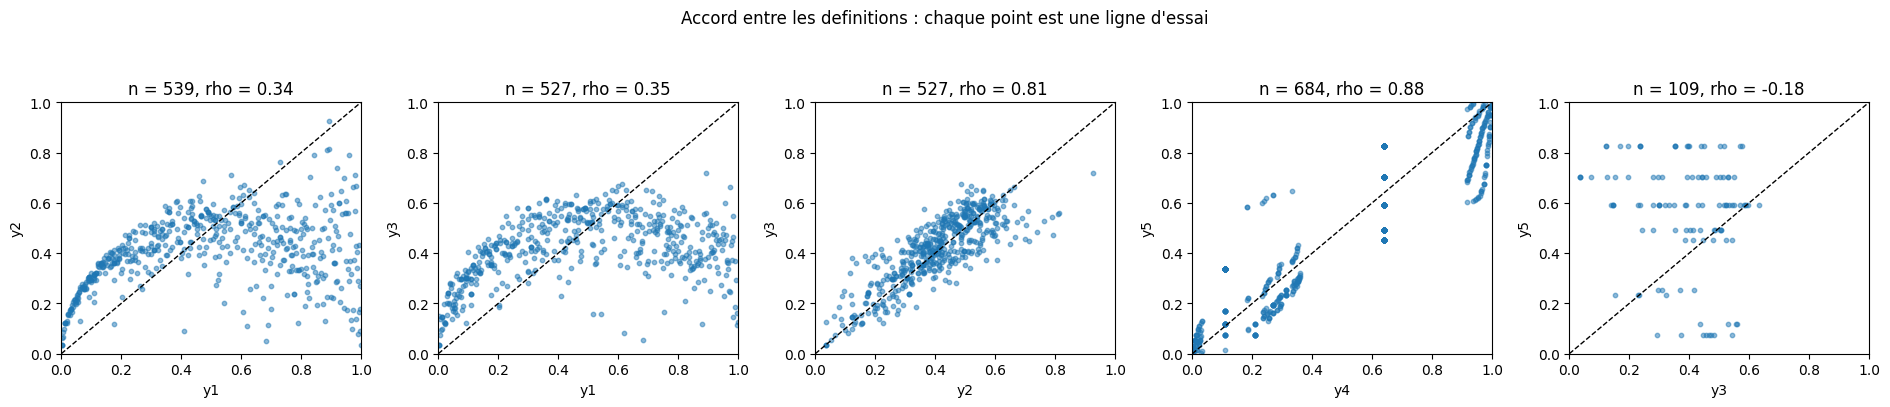

In [13]:
# Nuages deux a deux pour les paires les plus instructives.
paires_a_tracer = [("y1", "y2"), ("y1", "y3"), ("y2", "y3"),
                   ("y4", "y5"), ("y3", "y5")]

figure, axes = plt.subplots(1, len(paires_a_tracer), figsize=(19, 3.8))
for axe, (cible_a, cible_b) in zip(axes, paires_a_tracer):
    commun = cibles.loc[dev, [cible_a, cible_b]].dropna()
    axe.scatter(commun[cible_a], commun[cible_b], s=10, alpha=0.5)
    # La diagonale : les points qui s'y trouvent ont le meme rang dans les
    # deux definitions.
    axe.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
    rho = (spearmanr(commun[cible_a], commun[cible_b]).statistic
           if len(commun) > 10 else np.nan)
    axe.set(xlabel=cible_a, ylabel=cible_b, xlim=(0, 1), ylim=(0, 1),
            title=f"n = {len(commun)}, rho = {rho:.2f}")

figure.suptitle("Accord entre les definitions : chaque point est une ligne d'essai",
                y=1.06)
figure.tight_layout()
figure.savefig(OUT / "accord_definitions.png", dpi=150, bbox_inches="tight")
plt.show()

### Ce que montre l'accord

**Aucune paire n'atteint un accord proche de 1.** Selon la definition retenue,
on ne recommanderait donc pas les memes soudures. Le choix de la cible n'est pas
une formalite.

**y1 est tres loin de y2 et y3.** Avec des correlations de l'ordre de 0,33, et
un recouvrement du meilleur quintile tombant a moins de 10 % avec `y3`, predire
`UTS` seule produit un classement largement different du compromis. La
strategie 1 du notebook 01 n'est donc pas une simplification anodine de la
strategie 3 : c'est une autre definition de la qualite.

**y1 et la tenacite sont en opposition**, avec une correlation negative et un
recouvrement nul du meilleur quintile. Aucune des soudures les mieux classees
selon `UTS` ne figure parmi les mieux classees selon la tenacite. C'est la
confirmation chiffree de l'avertissement methodologique de l'introduction :
choisir `UTS` comme cible et recommander de la maximiser conduirait a
selectionner exactement les soudures les plus fragiles au choc.

**y2 et y3 sont proches sans etre interchangeables.** Leur correlation est
elevee, mais le recouvrement de leur meilleur quintile reste autour de 54 %.
Enrichir la cible de deux mesures modifie donc la recommandation pour pres d'une
soudure sur deux parmi les mieux notees. Ce n'est pas un raffinement cosmetique.

**y5 differe de y4, ce qui valide la correction de temperature.** Si classer la
tenacite a l'interieur de bandes de temperature ne changeait rien, les deux
candidates seraient confondues. Leur ecart mesure precisement l'effet de la
condition d'essai, que `y4` ignore et que `y5` neutralise.

**La tenacite reste quasi independante des cibles de traction.** Les
correlations avec `y3` sont tres faibles, sur un effectif reduit puisque peu de
publications ont realise les deux types d'essai. La tenacite au choc mesure donc
une propriete reellement distincte, ce qui plaide pour un modele separe plutot
que pour une integration au meme score.

### 3.3 Coherence physique

C'est le critere central de ce notebook, et celui qui repond directement a la
question posee : **une soudure bien notee par une definition est-elle vraiment
bonne ?**

#### Le principe, sur un exemple de dix soudures

Avant d'appliquer la methode aux 539 lignes du developpement, on la deroule sur
dix soudures pour que chaque etape soit visible.

**Etape A. Construire une regle graduee : le rang global.**
Pour chaque propriete, on classe les soudures de la pire a la meilleure, et on
remplace la valeur par sa **position** dans ce classement, ramenee entre 0 et 1.
Un rang de 0,25 signifie : un quart des soudures font moins bien qu'elle.

Ce rang n'est pas un pourcentage de qualite, c'est un pourcentage de position.
Et surtout, il est calcule **une fois pour toutes, sans regarder aucune
cible** : c'est ce qui en fait une regle de mesure neutre.

**Etape B. Calculer la cible a evaluer.**

**Etape C. Prendre les 20 % les MIEUX notees par cette cible.** Ce sont les
soudures qu'on recommanderait si on se fiait a cette definition. On ne
s'interesse pas aux mauvaises : si une definition classe mal une soudure
mediocre, c'est sans consequence.

**Etape D. Regarder, pour ces soudures, leur rang sur chaque propriete.** Si la
moyenne depasse 0,50, la definition a selectionne des soudures meilleures que la
moyenne du corpus sur cette propriete. Si elle est en dessous, elle a
selectionne des soudures mediocres.

In [14]:
# Demonstration de la methode sur dix soudures, a titre pedagogique.
# On prend dix lignes du developpement ou les trois mesures utilisees ici
# sont disponibles.
mesures_demo = ["UTS_MPa", "Elongation_pct", "ReductionArea_pct"]
demo = propre.loc[dev & domaine(mesures_demo), mesures_demo].sample(
    10, random_state=7).copy()


def rang_simple(serie):
    """Mi-rang sur une petite serie, sans ponderation : pour la demonstration.

    La i-eme valeur du classement sur n obtient le rang (i - 0,5) / n.
    """
    ordre = serie.rank(method="average")
    return (ordre - 0.5) / len(serie)


for mesure in mesures_demo:
    demo["rang_" + mesure] = rang_simple(demo[mesure])

# Etape B : la cible y2 sur ces dix soudures.
demo["y2_demo"] = np.sqrt(demo["rang_UTS_MPa"] * demo["rang_Elongation_pct"])

demo.sort_values("y2_demo", ascending=False).round(2)

,UTS_MPa,Elongation_pct,ReductionArea_pct,rang_UTS_MPa,rang_Elongation_pct,rang_ReductionArea_pct,y2_demo
row_id,,,,,,,
897,714.0,30.0,53.0,0.75,0.55,0.05,0.64
980,747.0,25.0,62.0,0.85,0.45,0.25,0.62
220,490.0,31.0,80.6,0.25,0.75,0.85,0.43
699,490.0,31.0,80.6,0.25,0.75,0.85,0.43
5,490.0,31.0,80.6,0.25,0.75,0.85,0.43
712,616.0,23.0,69.0,0.45,0.35,0.45,0.40
1162,647.0,22.0,60.0,0.55,0.25,0.15,0.37
1400,669.0,20.0,70.0,0.65,0.15,0.55,0.31
395,447.0,36.4,80.5,0.05,0.95,0.65,0.22


In [15]:
# Etape C : les deux meilleures selon y2, soit 20 % de dix.
deux_meilleures = demo.sort_values("y2_demo", ascending=False).head(2)

print("Les deux soudures que y2 juge les MEILLEURES :")
print(deux_meilleures[["y2_demo", "ReductionArea_pct",
                       "rang_ReductionArea_pct"]].round(2).to_string())

print("\nEtape D : leur rang moyen en striction")
print(f"   ces deux soudures         : {deux_meilleures['rang_ReductionArea_pct'].mean():.2f}")
print(f"   les dix soudures          : {demo['rang_ReductionArea_pct'].mean():.2f}")
print("\nLecture : y2 ne regarde pas la striction, donc rien ne l'empeche de")
print("selectionner des soudures mediocres sur cette propriete.")

Les deux soudures que y2 juge les MEILLEURES :
        y2_demo  ReductionArea_pct  rang_ReductionArea_pct
row_id                                                    
897        0.64               53.0                    0.05
980        0.62               62.0                    0.25

Etape D : leur rang moyen en striction
   ces deux soudures         : 0.15
   les dix soudures          : 0.50

Lecture : y2 ne regarde pas la striction, donc rien ne l'empeche de
selectionner des soudures mediocres sur cette propriete.


L'exemple montre le mecanisme : `y2` est construite sur `UTS` et l'allongement,
elle est donc necessairement bonne sur ces deux mesures. Mais la striction
n'entre pas dans son calcul, et rien ne garantit qu'elle soit satisfaisante.

#### Application aux cinq candidates

On applique maintenant la methode a l'ensemble du developpement, avec les rangs
calcules par soudure comme dans tout le reste du projet, et sur les cinq
proprietes retenues.

**Le test est volontairement exigeant : chaque cible est evaluee aussi sur des
proprietes qu'elle n'utilise pas.** Une definition fondee sur les proprietes de
traction sera jugee aussi sur la tenacite Charpy. C'est ce qui permet de
distinguer une definition qui capture quelque chose de reel d'une definition qui
n'est bonne que la ou elle regarde.

In [16]:
# Rang global de reference pour chaque mesure, calibre sur le developpement et
# independant de toute definition de cible. C'est la regle graduee commune.
rang_global = pd.DataFrame(index=propre.index)
for mesure in MESURES:
    calibration = propre[mesure].notna() & dev
    reference = reference_rangs(propre.loc[calibration, mesure],
                                groupes.loc[calibration])
    rang_global[mesure] = appliquer_rangs(propre[mesure], reference).where(
        propre[mesure].notna())

# Controle : par construction, la moyenne de chaque rang sur le developpement
# doit etre proche de 0,5.
print("moyenne des rangs globaux sur le developpement (attendue proche de 0,5) :")
print(rang_global.loc[dev].mean().round(3).to_string())

moyenne des rangs globaux sur le developpement (attendue proche de 0,5) :
YieldStrength_MPa    0.494
UTS_MPa              0.493
Elongation_pct       0.517
ReductionArea_pct    0.506
CharpyToughness_J    0.515


In [17]:
def profil_du_quintile(nom_cible):
    """Rang moyen de chaque propriete dans le meilleur quintile d'une cible."""
    serie = cibles.loc[dev, nom_cible].dropna()
    taille = int(np.ceil(0.20 * len(serie)))
    meilleures = serie.sort_values(ascending=False, kind="stable").head(taille).index

    profil = {"n_quintile": len(meilleures)}
    for mesure in MESURES:
        # Certaines proprietes ne sont pas renseignees pour toutes les lignes
        # du quintile : la moyenne porte sur celles qui le sont, et on note
        # l'effectif correspondant.
        disponibles = rang_global.loc[meilleures, mesure].dropna()
        profil[mesure] = disponibles.mean()
        profil["n_" + mesure] = len(disponibles)
    return profil


coherence = pd.DataFrame(
    [{"cible": n, **profil_du_quintile(n)} for n in COMPOSITION_CIBLES]
).set_index("cible")

# Synthese : l'equilibre entre les deux familles antagonistes.
coherence["moy_resistance"] = coherence[RESISTANCE].mean(axis=1)
coherence["moy_ductilite"] = coherence[DUCTILITE].mean(axis=1)
coherence["desequilibre"] = coherence["moy_resistance"] - coherence["moy_ductilite"]

# Combien de proprietes sont au-dessus du niveau moyen du corpus.
coherence["proprietes_au_dessus_de_0.5"] = (coherence[MESURES] > 0.5).sum(axis=1)

coherence[MESURES + ["moy_resistance", "moy_ductilite", "desequilibre",
                     "proprietes_au_dessus_de_0.5"]].round(3)

,YieldStrength_MPa,UTS_MPa,Elongation_pct,ReductionArea_pct,CharpyToughness_J,moy_resistance,moy_ductilite,desequilibre,proprietes_au_dessus_de_0.5
cible,,,,,,,,,
y1,0.837,0.902,0.231,0.189,0.292,0.870,0.210,0.660,2
y2,0.572,0.641,0.602,0.428,0.424,0.607,0.515,0.092,3
y3,0.588,0.554,0.587,0.660,0.552,0.571,0.623,-0.053,5
y4,0.087,0.058,0.919,0.919,0.944,0.073,0.919,-0.846,3
y5,0.215,0.239,0.717,0.693,0.823,0.227,0.705,-0.478,3


In [18]:
# Les effectifs sur lesquels chaque moyenne est calculee, pour transparence.
coherence[["n_quintile"] + ["n_" + m for m in MESURES]]

,n_quintile,n_YieldStrength_MPa,n_UTS_MPa,n_Elongation_pct,n_ReductionArea_pct,n_CharpyToughness_J
cible,,,,,,
y1,120,116,120,108,102,20
y2,108,108,108,108,105,22
y3,106,106,106,106,106,15
y4,137,3,3,3,3,137
y5,137,19,19,19,19,137


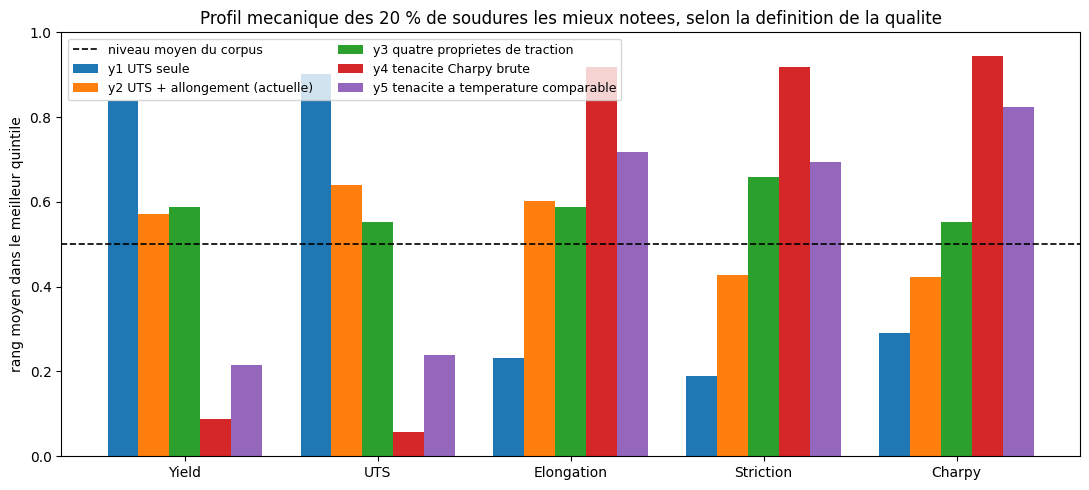

In [19]:
# Visualisation : profil mecanique du meilleur quintile de chaque cible.
etiquettes = ["Yield", "UTS", "Elongation", "Striction", "Charpy"]
positions = np.arange(len(MESURES))
largeur = 0.16

figure, axe = plt.subplots(figsize=(11, 5))
for rang_barre, nom in enumerate(COMPOSITION_CIBLES):
    decalage = (rang_barre - 2) * largeur
    axe.bar(positions + decalage, coherence.loc[nom, MESURES].to_numpy(),
            largeur, label=LIBELLES[nom])

axe.axhline(0.5, color="black", linestyle="--", linewidth=1.2,
            label="niveau moyen du corpus")
axe.set_xticks(positions)
axe.set_xticklabels(etiquettes)
axe.set_ylabel("rang moyen dans le meilleur quintile")
axe.set_ylim(0, 1)
axe.set_title("Profil mecanique des 20 % de soudures les mieux notees, "
              "selon la definition de la qualite")
axe.legend(fontsize=9, ncol=2)

figure.tight_layout()
figure.savefig(OUT / "coherence_physique.png", dpi=150)
plt.show()

### Ce que montre la coherence physique

Le graphique se lit par comparaison a la ligne pointillee, qui represente le
niveau moyen du corpus. Une barre au-dessus signifie que la definition
selectionne des soudures meilleures que la moyenne sur cette propriete ; une
barre en dessous, qu'elle selectionne des soudures mediocres.

**y1 est disqualifiee.** Son meilleur quintile est excellent en resistance,
puisque c'est exactement ce qu'elle mesure, mais s'effondre en ductilite : les
soudures qu'elle designe comme les meilleures figurent parmi les moins ductiles
du corpus. Leur rang en tenacite Charpy est egalement tres faible.

En termes concrets : si l'on construisait un modele pour maximiser `UTS`, on
recommanderait des soudures tres resistantes et tres fragiles. La section 1
a rappele que la rupture fragile survient sans deformation prealable, donc sans
signe d'alerte. C'est le mode de defaillance que les normes cherchent justement
a prevenir.

**y4 est le miroir exact de y1.** Son quintile superieur est excellent en
ductilite et en tenacite, et tres faible en resistance. La tenacite seule ne
definit donc pas davantage la qualite que la resistance seule : les deux
definitions souffrent du meme defaut, dans des directions opposees.

**y5 presente le meme desequilibre que y4**, ce qui est attendu puisqu'elle
mesure la meme propriete. La correction de temperature ne change pas la famille
physique evaluee, elle rend seulement le classement plus juste a l'interieur de
cette famille.

**y2, la cible actuelle du projet, est correcte mais incomplete.** Son
desequilibre entre les deux familles est faible, ce qui valide le principe du
compromis. Mais deux proprietes de son quintile superieur restent **sous le
niveau moyen du corpus** : la striction et la tenacite Charpy. Autrement dit,
`y2` protege ce qu'elle regarde et laisse passer le reste.

**y3 est la definition la plus equilibree.** Son desequilibre est le plus faible
en valeur absolue, et c'est **la seule candidate dont le quintile superieur est
au-dessus du niveau moyen du corpus sur les cinq proprietes**.

Ce dernier point merite d'etre souligne, car c'est l'argument le plus fort de ce
notebook : **la tenacite Charpy n'entre pas dans le calcul de y3**, et pourtant
son quintile superieur y est meilleur que la moyenne. La definition generalise
donc a une propriete qu'elle n'observe pas.

> **Un bon indicateur de qualite doit predire la qualite au-dela de ce qu'il
> mesure.** C'est ce que fait `y3`, et ce que ne font ni `y1`, ni `y2`, ni `y4`,
> ni `y5`.

### 3.4 Robustesse

Une definition de la qualite n'est exploitable que si son classement ne depend
pas trop de l'echantillon dont on dispose. Si retirer quelques soudures
bouleversait le palmares, la definition ne serait pas fiable.

#### Le principe du bootstrap

On simule le fait d'avoir collecte un echantillon legerement different. Pour
cela, on **tire au hasard, avec remise**, autant de soudures qu'il y en a dans
le developpement. Certaines seront tirees plusieurs fois, d'autres pas du tout :
on obtient ainsi un echantillon plausible mais different. On recalcule alors les
rangs et la cible sur cet echantillon, et on regarde si le meilleur quintile
reste le meme. L'operation est repetee trente fois.

Deux precisions importantes.

**Le tirage porte sur les soudures, pas sur les lignes.** Tirer des lignes
casserait les groupes et melangerait les etats d'une meme soudure, ce qui serait
incoherent avec le reste du projet.

**La mesure d'accord est l'indice de Jaccard.** C'est le rapport entre le nombre
de soudures communes aux deux quintiles et le nombre total de soudures
apparaissant dans l'un ou l'autre :

```
Jaccard  =  taille de l'intersection  /  taille de l'union
```

Il vaut 1 si les deux quintiles sont identiques, et 0 s'ils n'ont aucune
soudure en commun. Une valeur de 0,80 signifie qu'environ 80 % des soudures
recommandees sont les memes avant et apres perturbation.

In [20]:
generateur = np.random.default_rng(GRAINE)
groupes_dev = groupes[dev]
liste_groupes = np.sort(groupes_dev.unique())
N_TIRAGES = 30


def quintile_de(serie):
    """Indices du meilleur cinquieme des valeurs disponibles."""
    valides = serie.dropna()
    taille = int(np.ceil(0.20 * len(valides)))
    return set(valides.sort_values(ascending=False, kind="stable").head(taille).index)


def cible_sur_echantillon(nom, mesures_exigees, lignes_calibration):
    """Recalcule une cible en calibrant les rangs sur les lignes fournies."""
    if nom == "y5":
        valeur = pd.Series(np.nan, index=propre.index)
        for bande in bande_temperature.cat.categories:
            dans_bande = bande_temperature == bande
            calibration_bande = propre.index.isin(lignes_calibration) & dans_bande
            if calibration_bande.sum() < 10:
                continue
            reference = reference_rangs(
                propre.loc[calibration_bande, "CharpyToughness_J"],
                groupes.loc[calibration_bande])
            lignes_bande = dans_bande & domaine(mesures_exigees)
            valeur.loc[lignes_bande] = appliquer_rangs(
                propre.loc[lignes_bande, "CharpyToughness_J"], reference)
        return valeur

    rangs_echantillon = pd.DataFrame(index=propre.index)
    for mesure in mesures_exigees:
        reference = reference_rangs(propre.loc[lignes_calibration, mesure],
                                    groupes.loc[lignes_calibration])
        rangs_echantillon[mesure] = appliquer_rangs(propre[mesure], reference)

    if nom == "y3":
        valeur = np.sqrt(rangs_echantillon[RESISTANCE].mean(axis=1)
                         * rangs_echantillon[DUCTILITE].mean(axis=1))
    elif len(mesures_exigees) == 2:
        valeur = np.sqrt(rangs_echantillon.prod(axis=1))
    else:
        valeur = rangs_echantillon[mesures_exigees[0]]
    return valeur.where(domaine(mesures_exigees))


lignes_robustesse = []
for nom, mesures_exigees in COMPOSITION_CIBLES.items():
    quintile_reference = quintile_de(cibles.loc[dev, nom])
    jaccards = []

    for _ in range(N_TIRAGES):
        tirage = generateur.choice(liste_groupes, size=len(liste_groupes),
                                   replace=True)
        lignes_tirees = groupes_dev[groupes_dev.isin(np.unique(tirage))].index
        calibration = lignes_tirees[domaine(mesures_exigees).loc[lignes_tirees]]
        if len(calibration) < 30:
            continue

        valeur = cible_sur_echantillon(nom, mesures_exigees, calibration)
        quintile_tirage = quintile_de(valeur.loc[dev])

        intersection = len(quintile_reference & quintile_tirage)
        union = len(quintile_reference | quintile_tirage)
        jaccards.append(intersection / union)

    lignes_robustesse.append({
        "cible": LIBELLES[nom],
        "tirages_retenus": len(jaccards),
        "jaccard_moyen": np.mean(jaccards),
        "jaccard_minimum": np.min(jaccards),
    })

robustesse = pd.DataFrame(lignes_robustesse).set_index("cible")
robustesse.round(3)

,tirages_retenus,jaccard_moyen,jaccard_minimum
cible,,,
y1 UTS seule,30,1.000,1.000
y2 UTS + allongement (actuelle),30,0.929,0.785
y3 quatre proprietes de traction,30,0.931,0.812
y4 tenacite Charpy brute,30,1.000,1.000
y5 tenacite a temperature comparable,30,0.922,0.734


### Ce que montre la robustesse

**Un piege de lecture a eviter : les cibles a une seule mesure obtiennent 1,000,
et ce n'est pas un signe de superiorite.** Une cible fondee sur une seule mesure
est une transformation monotone de cette mesure : le rang preserve l'ordre.
Recalibrer les rangs sur un autre echantillon change donc les valeurs du score,
mais jamais l'ordre des soudures, donc jamais la composition du quintile
superieur. Ces cibles sont **trivialement invariantes**, et non robustes.

**La comparaison pertinente est entre y2 et y3**, les deux seules cibles
composites, puisque ce sont les seules dont le classement peut reellement
changer. Toutes deux sont stables, et `y3` l'est legerement plus, en moyenne
comme dans le pire tirage. Combiner quatre mesures au lieu de deux moyenne
davantage le bruit experimental, ce qui etait l'effet attendu.

L'ecart entre les deux est faible et ne suffirait pas a lui seul a trancher.
Mais il va dans le meme sens que le critere de coherence physique, ce qui
renforce la conclusion.

### 3.5 Synthese de la comparaison sans modele

Les quatre criteres, reunis. Aucun modele n'a encore ete entraine : tout ce qui
precede repose sur la structure des donnees et sur la physique des proprietes
mesurees.

In [21]:
synthese = pd.DataFrame({
    "lignes_exploitables": couverture.loc[
        [LIBELLES[n] for n in COMPOSITION_CIBLES], "lignes_total"].to_numpy(),
    "desequilibre_absolu": coherence["desequilibre"].abs().round(3).to_numpy(),
    "proprietes_au_dessus_moyenne": coherence[
        "proprietes_au_dessus_de_0.5"].to_numpy(),
    "jaccard_moyen": robustesse["jaccard_moyen"].round(3).to_numpy(),
}, index=[LIBELLES[n] for n in COMPOSITION_CIBLES])

synthese["mesures_combinees"] = [len(COMPOSITION_CIBLES[n])
                                 for n in COMPOSITION_CIBLES]
synthese = synthese[["mesures_combinees", "lignes_exploitables",
                     "desequilibre_absolu", "proprietes_au_dessus_moyenne",
                     "jaccard_moyen"]]

# Conserver la synthese pour le rapport.
synthese.to_csv(OUT / "synthese_criteres.csv", index_label="cible")
couverture.to_csv(OUT / "couverture.csv", index_label="cible")
accords.to_csv(OUT / "accords.csv", index_label="paire")
coherence.to_csv(OUT / "coherence_physique.csv", index_label="cible")
robustesse.to_csv(OUT / "robustesse.csv", index_label="cible")

synthese

,mesures_combinees,lignes_exploitables,desequilibre_absolu,proprietes_au_dessus_moyenne,jaccard_moyen
y1 UTS seule,1,738,0.660,2,1.000
y2 UTS + allongement (actuelle),2,666,0.092,3,0.929
y3 quatre proprietes de traction,4,650,0.053,5,0.931
y4 tenacite Charpy brute,1,879,0.846,3,1.000
y5 tenacite a temperature comparable,2,879,0.478,3,0.922


### Conclusion provisoire

**Les definitions a une seule mesure sont ecartees.** `y1`, `y4` et `y5`
recompensent chacune une seule famille de proprietes au detriment de l'autre.
Leur quintile superieur est excellent sur ce qu'elles mesurent et mediocre sur
le reste. Compte tenu du caractere antagoniste des deux familles etabli en
section 1.4, aucune ne constitue une definition acceptable de la qualite d'une
soudure prise isolement.

**Entre les deux definitions composites, y3 domine y2.** Elle est plus
equilibree entre les deux familles, c'est la seule dont le quintile superieur
depasse le niveau moyen du corpus sur les cinq proprietes, et elle est
legerement plus robuste. Le cout de ce passage est de seize lignes, soit 2,4 %
des donnees disponibles.

**La tenacite conserve un interet distinct.** Les candidates `y4` et `y5`
couvrent le plus grand nombre de lignes et mesurent une propriete quasi
independante des proprietes de traction. Elles ne doivent pas etre integrees au
meme score, mais traitees comme une **seconde cible dans un second modele**,
ce qui correspond a la strategie 2 recensee au notebook 01 et a l'approche
retenue par les auteurs du jeu de donnees. Entre les deux, `y5` est preferable
car elle neutralise l'effet de la temperature d'essai.

Ces conclusions reposent entierement sur la structure des donnees. Les sections
suivantes verifient qu'elles resistent a l'epreuve de la modelisation.

## 4. Comparer avec un modele

La section 3 a etabli ses conclusions sans aucun modele, a partir de la seule
structure des donnees. On verifie maintenant qu'elles resistent a la
modelisation, et on en profite pour repondre a une seconde question : **quelles
variables d'entree comptent le plus**, et cette reponse depend-elle de la cible
choisie ?

### 4.1 Protocole

**Un seul modele, plusieurs cibles.** Pour que la comparaison soit
interpretable, une seule chose doit varier : la cible. On fixe donc tout le
reste.

Le modele retenu est la **foret aleatoire avec exactement les hyperparametres
selectionnes par le notebook 05** : profondeur maximale 20, 25 % des variables
candidates a chaque division, une ligne minimum par feuille, 500 arbres. Ce
n'est pas un choix d'opportunite : en reprenant la configuration deja validee
par l'equipe, on s'assure que les resultats de cette section sont directement
comparables a ceux du notebook 05.

**La preparation des entrees est celle du notebook 03** : seuil de remplissage
a 25 %, imputation par la mediane pour les variables numeriques, categorie
`manquant` et encodage one-hot pour les variables categorielles. Pas de
standardisation, inutile pour un modele a base d'arbres.

**Le protocole de validation est celui du notebook 05** : cinq plis par
groupes, avec reajustement complet dans chaque pli. Trois choses sont refaites
a chaque pli :

- la **selection des colonnes** et les **medianes d'imputation**, calculees sur
  l'apprentissage du pli seulement ;
- les **rangs de la cible**, recalibres sur l'apprentissage du pli ;
- la **ponderation par groupe**, pour l'entrainement comme pour l'evaluation.

Cette derniere precaution est essentielle et vaut d'etre rappelee : la cible
etant un rang, elle depend des donnees. La calibrer une fois pour toutes sur
l'ensemble du developpement ferait fuir vers l'apprentissage une information
issue des lignes de validation.

**Les cibles comparees.** On retient `y1`, `y2` et `y3`, qui partagent le meme
domaine de definition a quelques lignes pres, donc sont directement
comparables. On ajoute `y5` separement, car elle porte sur d'autres lignes : les
essais Charpy, qui sont plus nombreux. La candidate `y4` est ecartee, `y5` la
dominant sur le critere de coherence.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, export_text

# Variables d'entree : composition chimique et parametres du procede.
# Les proprietes mecaniques en sont exclues, puisqu'elles servent a
# construire la cible.
VARIABLES_ENTREE = schema["COMPOSITION"] + schema["PROCESS"]
CATEGORIELLES = ["AC_DC", "Electrode_pol", "WeldType"]

assert not set(VARIABLES_ENTREE) & set(TOUTES_MECANIQUES), \
    "une propriete mecanique s'est glissee dans les entrees"

# Hyperparametres exacts retenus par le notebook 05.
HYPERPARAMETRES_FORET = dict(max_depth=20, max_features=0.25,
                             min_samples_leaf=1, n_estimators=500,
                             random_state=GRAINE, n_jobs=-1)

print(f"{len(VARIABLES_ENTREE)} variables d'entree, dont "
      f"{len(CATEGORIELLES)} categorielles.")
print("Hyperparametres de la foret :", HYPERPARAMETRES_FORET)

30 variables d'entree, dont 3 categorielles.
Hyperparametres de la foret : {'max_depth': 20, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 500, 'random_state': 42, 'n_jobs': -1}


In [23]:
def creer_preparation(X_apprentissage, seuil=0.25):
    """Preparation des entrees, reprise du notebook 03.

    La selection des colonnes repose uniquement sur l'apprentissage fourni :
    une colonne trop peu renseignee dans ce pli est ecartee de ce pli.
    """
    taux_remplissage = X_apprentissage.notna().mean()
    gardees = taux_remplissage[taux_remplissage >= seuil].index.tolist()
    numeriques = [c for c in gardees if c not in CATEGORIELLES]
    categorielles = [c for c in gardees if c in CATEGORIELLES]

    return ColumnTransformer([
        ("nombres", SimpleImputer(strategy="median"), numeriques),
        ("categories", Pipeline([
            ("manquants", SimpleImputer(strategy="constant",
                                        fill_value="manquant")),
            ("encodage", OneHotEncoder(drop="first", handle_unknown="ignore",
                                       sparse_output=False)),
        ]), categorielles),
    ])


def cible_calibree_sur(nom, mesures_exigees, lignes_calibration):
    """Recalcule une cible en calibrant ses rangs sur les lignes fournies.

    Utilisee dans chaque pli de validation croisee, pour que la cible de
    validation soit construite avec la reference de l'apprentissage.
    """
    return cible_sur_echantillon(nom, mesures_exigees, lignes_calibration)


def evaluer_cible(nom, mesures_exigees, modele, n_plis=5):
    """Validation croisee par groupes d'un modele sur une cible donnee.

    Renvoie les erreurs du modele et celles d'une reference constante, pli par
    pli. La reference predit la moyenne ponderee de l'apprentissage : c'est le
    minimum qu'un modele doit battre pour etre utile.
    """
    disponible = domaine(mesures_exigees) & dev
    index = propre.index[disponible]
    X = propre.loc[index, VARIABLES_ENTREE]
    groupes_locaux = groupes.loc[index]

    resultats = []
    for numero, (train, validation) in enumerate(
            GroupKFold(n_splits=n_plis).split(X, groups=groupes_locaux), start=1):
        index_train, index_val = index[train], index[validation]
        assert set(groupes.loc[index_train]).isdisjoint(
            set(groupes.loc[index_val]))

        # La cible est recalibree sur l'apprentissage de ce pli.
        y = cible_calibree_sur(nom, mesures_exigees, index_train)
        poids_train = poids_par_groupe(groupes.loc[index_train]).to_numpy()
        poids_val = poids_par_groupe(groupes.loc[index_val]).to_numpy()

        preparation = creer_preparation(X.loc[index_train])

        pipeline = Pipeline([("preparation", preparation),
                             ("modele", modele)])
        pipeline.fit(X.loc[index_train], y.loc[index_train],
                     modele__sample_weight=poids_train)
        prediction = pipeline.predict(X.loc[index_val])

        reference = Pipeline([("preparation", creer_preparation(X.loc[index_train])),
                              ("modele", DummyRegressor(strategy="mean"))])
        reference.fit(X.loc[index_train], y.loc[index_train],
                      modele__sample_weight=poids_train)
        prediction_reference = reference.predict(X.loc[index_val])

        resultats.append({
            "cible": nom, "pli": numero,
            "n_train": len(index_train), "n_val": len(index_val),
            "rmse_modele": np.sqrt(mean_squared_error(
                y.loc[index_val], prediction, sample_weight=poids_val)),
            "rmse_reference": np.sqrt(mean_squared_error(
                y.loc[index_val], prediction_reference, sample_weight=poids_val)),
            "r2_modele": r2_score(y.loc[index_val], prediction,
                                  sample_weight=poids_val),
        })

    return pd.DataFrame(resultats)


print("fonctions d'evaluation definies")

fonctions d'evaluation definies


### 4.2 Pourquoi on ne peut pas comparer les RMSE directement

Avant de regarder les resultats, un point de methode qu'il serait facile de
negliger.

La RMSE, pour *root mean squared error*, est la racine de la moyenne des carres
des ecarts entre prediction et valeur reelle. Elle s'exprime dans l'unite de la
cible, et **plus elle est faible, mieux c'est**.

Mais nos cinq cibles, bien qu'elles vivent toutes entre 0 et 1, n'ont pas la
meme **dispersion**. Une cible dont les valeurs sont tres etalees sera
mecaniquement associee a des erreurs plus grandes qu'une cible dont les valeurs
sont resserrees, independamment de la qualite du modele.

Comparer les RMSE brutes reviendrait donc a comparer des grandeurs
inhomogenes.

**La solution : mesurer le gain par rapport a une reference.** Pour chaque
cible, on entraine aussi un predicteur trivial qui annonce toujours la moyenne
de l'apprentissage, sans regarder les variables d'entree. C'est le minimum
qu'un modele doit battre pour etre utile. On calcule alors :

```
gain  =  1  -  RMSE du modele  /  RMSE de la reference
```

Un gain de 0,40 signifie que le modele reduit de 40 % l'erreur d'un predicteur
qui ne sait rien. Cette grandeur est **sans unite**, donc comparable d'une cible
a l'autre.

> **Rappel de l'avertissement de l'introduction.** Ce gain mesure la
> **predictibilite** d'une cible, c'est-a-dire a quel point la composition et le
> procede permettent de la deviner. Il ne mesure pas sa **pertinence** comme
> definition de la qualite. Les deux sont independants, et la suite va le
> montrer de facon assez spectaculaire.

In [24]:
cibles_a_evaluer = {
    "y1": COMPOSITION_CIBLES["y1"],
    "y2": COMPOSITION_CIBLES["y2"],
    "y3": COMPOSITION_CIBLES["y3"],
    "y5": COMPOSITION_CIBLES["y5"],
}

resultats_plis = []
for nom, mesures_exigees in cibles_a_evaluer.items():
    resultats_plis.append(
        evaluer_cible(nom, mesures_exigees,
                      RandomForestRegressor(**HYPERPARAMETRES_FORET)))

resultats_plis = pd.concat(resultats_plis, ignore_index=True)

predictibilite = resultats_plis.groupby("cible").agg(
    lignes=("n_val", "sum"),
    rmse_modele=("rmse_modele", "mean"),
    ecart_type_rmse=("rmse_modele", "std"),
    rmse_reference=("rmse_reference", "mean"),
    r2=("r2_modele", "mean"),
)
predictibilite["gain_sur_reference"] = (
    1 - predictibilite["rmse_modele"] / predictibilite["rmse_reference"])
predictibilite = predictibilite.reindex([c for c in cibles_a_evaluer])
predictibilite.round(4)

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


...

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,lignes,rmse_modele,ecart_type_rmse,rmse_reference,r2,gain_sur_reference
cible,,,,,,
y1,599,0.1413,0.0094,0.2898,0.7542,0.5124
y2,539,0.1030,0.0090,0.1501,0.5179,0.3137
y3,527,0.0825,0.0120,0.1318,0.5925,0.3738
y5,684,0.1834,0.0086,0.2472,0.4413,0.2582


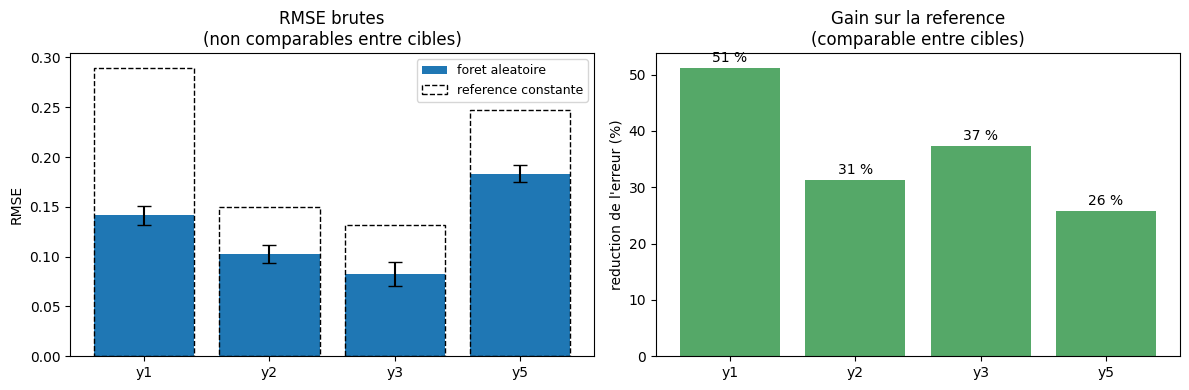

In [25]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

# A gauche : les RMSE brutes, qui ne sont PAS comparables entre cibles.
axes[0].bar(predictibilite.index, predictibilite["rmse_modele"],
            yerr=predictibilite["ecart_type_rmse"], capsize=5,
            label="foret aleatoire")
axes[0].bar(predictibilite.index, predictibilite["rmse_reference"],
            fill=False, edgecolor="black", linestyle="--",
            label="reference constante")
axes[0].set(ylabel="RMSE", title="RMSE brutes\n(non comparables entre cibles)")
axes[0].legend(fontsize=9)

# A droite : le gain, sans unite, donc comparable.
axes[1].bar(predictibilite.index, 100 * predictibilite["gain_sur_reference"],
            color="#55A868")
axes[1].set(ylabel="reduction de l'erreur (%)",
            title="Gain sur la reference\n(comparable entre cibles)")
for position, valeur in enumerate(100 * predictibilite["gain_sur_reference"]):
    axes[1].text(position, valeur + 1, f"{valeur:.0f} %", ha="center")

figure.tight_layout()
figure.savefig(OUT / "predictibilite_cibles.png", dpi=150)
plt.show()

### 4.3 Ce que montre la predictibilite

Deux resultats, et le premier confirme l'avertissement de l'introduction de
facon frappante.

**y1 est de loin la cible la plus facile a predire** : 51 % de reduction de
l'erreur, contre 37 % pour `y3` et 31 % pour `y2`. Son R2 atteint 0,75, la
meilleure valeur de tout le projet. C'etait attendu : `y1` ne combine qu'une
seule mesure, donc elle agrege le bruit d'un seul essai et ne represente qu'une
seule dimension physique.

> **Si l'on avait choisi la cible par la qualite de prediction, on aurait retenu
> `y1`.** Or la section 3.3 a montre que son quintile superieur est constitue des
> soudures les moins ductiles et les moins tenaces du corpus. On aurait donc
> construit un modele excellent pour recommander des soudures fragiles.
>
> C'est la demonstration pratique de l'avertissement place en tete de ce
> notebook : **le R2 et le gain mesurent la predictibilite, pas la pertinence.**

**Second resultat, et il leve la principale objection au changement de cible :
y3 n'est pas plus difficile a predire que y2.** Son R2 vaut 0,59 contre 0,52,
son gain 37 % contre 31 %, et sa RMSE brute est plus faible. Elle est meilleure
sur les trois indicateurs a la fois.

On pouvait craindre l'inverse : combiner quatre mesures au lieu de deux agrege
le bruit de quatre essais, ce qui aurait pu rendre la cible plus bruitee donc
moins predictible. L'effet observe est le contraire, et il s'explique : moyenner
deux mesures a l'interieur de chaque famille **reduit** le bruit propre a chaque
essai plutot que de l'accumuler, puisque les deux mesures d'une meme famille
sont fortement correlees. Le signal physique en ressort plus net.

**y5 est la cible la moins predictible**, malgre un nombre de lignes plus
eleve. Deux raisons, toutes deux attendues.

D'une part la tenacite Charpy est une mesure reputee tres dispersee : elle
depend fortement de la microstructure locale a l'endroit precis de l'entaille,
donc deux eprouvettes decoupees dans la meme soudure peuvent donner des
resultats sensiblement differents. Cette dispersion est un bruit que ni la
composition ni le procede ne peuvent expliquer.

D'autre part le classement par bande de temperature, introduit en section 2
pour rendre les essais comparables, retire volontairement de la cible la
variable qui explique le mieux la tenacite, a savoir la temperature d'essai. Ce
qui reste a predire est donc plus difficile, par construction.

Cela ne disqualifie pas la tenacite comme critere de qualite : les auteurs du
jeu de donnees ont precisement entraine un reseau de neurones sur cette
grandeur, et la jugent la plus importante pour une soudure. Cela signifie
simplement qu'un modele de tenacite sera moins precis, et devra etre presente
comme tel.

> **Conclusion de cette section.** Le critere de predictibilite ne contredit pas
> celui de coherence physique : il le renforce. `y3` est a la fois la definition
> la plus equilibree physiquement et la mieux predite des deux definitions
> composites. Le changement de cible ne coute donc rien en performance.

### 4.4 Quelles variables comptent, et cela depend-il de la cible ?

Une foret de 500 arbres n'est pas lisible directement. Pour savoir ce qu'elle a
appris, on utilise l'**importance par permutation**, qui est la methode que le
cours recommande dans le cadre des forets aleatoires.

#### Le principe, en une phrase

On prend un modele deja entraine, on **melange au hasard les valeurs d'une
seule variable** entre les lignes, et on regarde de combien l'erreur augmente.
Si melanger une variable degrade beaucoup les predictions, c'est que le modele
s'appuyait dessus : elle est importante. Si l'erreur ne bouge pas, la variable
ne servait a rien.

L'operation est repetee dix fois par variable, avec des melanges differents,
pour que le resultat ne depende pas d'un tirage particulier.

#### Pourquoi cette methode plutot que `feature_importances_`

Scikit-learn propose un attribut `feature_importances_`, fonde sur la
decroissance d'impurete accumulee lors des divisions. Il est instantane, mais le
cours signale qu'il est **biaise** : il surevalue les variables continues et
celles qui prennent beaucoup de valeurs differentes, simplement parce qu'elles
offrent davantage de points de coupure possibles.

L'importance par permutation ne souffre pas de ce biais. Elle a en revanche sa
propre limite, egalement signalee par le cours : lorsque deux variables sont
fortement correlees, melanger l'une seule peut ne pas degrader les predictions,
le modele retrouvant l'information dans l'autre. L'importance des variables
correlees est alors sous-estimee, et repartie entre elles. Il faut garder ce
point en tete pour l'interpretation : une variable d'importance faible n'est pas
necessairement inutile.

In [26]:
def importance_par_permutation(nom, mesures_exigees, n_repetitions=10):
    """Importance par permutation, sur un modele ajuste sur tout le developpement."""
    disponible = domaine(mesures_exigees) & dev
    index = propre.index[disponible]
    X = propre.loc[index, VARIABLES_ENTREE]
    y = cible_calibree_sur(nom, mesures_exigees, index).loc[index]
    poids = poids_par_groupe(groupes.loc[index]).to_numpy()

    pipeline = Pipeline([("preparation", creer_preparation(X)),
                         ("modele", RandomForestRegressor(**HYPERPARAMETRES_FORET))])
    pipeline.fit(X, y, modele__sample_weight=poids)

    resultat = permutation_importance(
        pipeline, X, y, n_repeats=n_repetitions, random_state=GRAINE,
        n_jobs=-1, scoring="neg_root_mean_squared_error")

    return pd.Series(resultat.importances_mean, index=X.columns)


importances = pd.DataFrame({
    nom: importance_par_permutation(nom, mesures)
    for nom, mesures in cibles_a_evaluer.items()
})

# Classement selon la cible retenue a l'issue de la section 3.
importances_triees = importances.sort_values("y3", ascending=False)
importances_triees.head(15).round(4)

,y1,y2,y3,y5
Mn,0.1070,0.0658,0.0596,0.0077
PWHT_T_C,0.0249,0.0130,0.0217,0.0041
Si,0.0339,0.0211,0.0198,0.0040
O_ppm,0.0193,0.0190,0.0188,0.0057
PWHT_time_h,0.0150,0.0115,0.0166,0.0029
C,0.0328,0.0172,0.0156,0.0049
P,0.0167,0.0130,0.0155,0.0047
HeatInput_kJmm,0.0099,0.0097,0.0128,0.0023
N_ppm,0.0329,0.0115,0.0121,0.0060
S,0.0115,0.0094,0.0119,0.0024


In [27]:
# Les dix variables les plus importantes pour y3, et leur rang pour les autres
# cibles, afin de voir si la reponse depend de la definition retenue.
rangs_importance = importances.rank(ascending=False).astype(int)
comparaison_rangs = rangs_importance.loc[importances_triees.head(10).index]
comparaison_rangs.columns = ["rang pour " + c for c in comparaison_rangs.columns]
comparaison_rangs

,rang pour y1,rang pour y2,rang pour y3,rang pour y5
Mn,2,1,1,1
PWHT_T_C,10,7,2,9
Si,7,2,3,10
O_ppm,11,4,4,4
PWHT_time_h,13,9,5,12
C,9,6,6,5
P,12,8,7,7
HeatInput_kJmm,18,12,8,15
N_ppm,8,10,9,3
S,17,13,10,14


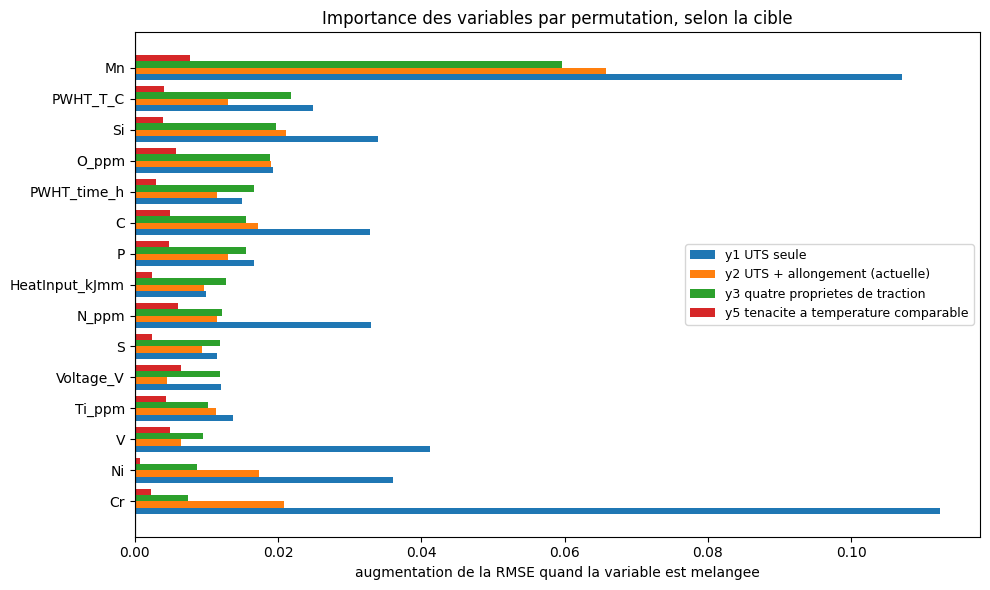

In [28]:
figure, axe = plt.subplots(figsize=(10, 6))
quinze_premieres = importances_triees.head(15).iloc[::-1]
positions = np.arange(len(quinze_premieres))
largeur = 0.2

for decalage, nom in zip([-1.5, -0.5, 0.5, 1.5], cibles_a_evaluer):
    axe.barh(positions + decalage * largeur, quinze_premieres[nom],
             largeur, label=LIBELLES[nom])

axe.set_yticks(positions)
axe.set_yticklabels(quinze_premieres.index)
axe.set_xlabel("augmentation de la RMSE quand la variable est melangee")
axe.set_title("Importance des variables par permutation, selon la cible")
axe.legend(fontsize=9)
axe.axvline(0, color="black", linewidth=0.8)

figure.tight_layout()
figure.savefig(OUT / "importance_variables.png", dpi=150)
plt.show()

### Ce que montrent les importances

Le tableau de rangs ci-dessus est le resultat le plus instructif de cette
section, parce qu'il montre que **la reponse a la question "quelles variables
comptent" change completement selon la cible**.

**Un seul point commun : le manganese.** Il est premier pour `y2`, `y3` et
`y5`, et deuxieme pour `y1`. C'est coherent avec la nature du corpus, qui est
constitue pour l'essentiel d'aciers au carbone-manganese : le manganese y est
l'element d'alliage principal, il augmente la resistance et participe a la
desoxydation du bain de fusion. Quelle que soit la definition de la qualite
retenue, il ressort.

**Pour y1, la resistance seule, ce sont les elements d'alliage qui dominent** :
chrome, manganese, molybdene, puis niobium, vanadium et nickel. C'est le
mecanisme classique du durcissement par alliage et par precipitation. Ces six
variables suffisent presque, ce qui explique au passage pourquoi `y1` est si
facile a predire : la resistance mecanique est une propriete largement
gouvernee par la composition d'alliage.

**Pour y3, la cible equilibree, le classement se deplace vers le procede et les
impuretes** : le traitement thermique post-soudage remonte de la 10e a la 2e
place, sa duree de la 13e a la 5e, l'energie de soudage de la 18e a la 8e, et
le phosphore de la 12e a la 7e. C'est metallurgiquement logique et c'est meme
le point le plus interessant : le traitement thermique post-soudage sert
precisement a restaurer de la ductilite apres soudage. Il n'a donc aucune
raison de ressortir quand on ne mesure que la resistance, et toutes les raisons
de ressortir des que la ductilite entre dans la cible.

**Pour y5, la tenacite, ce sont l'oxygene et l'azote qui remontent** aux 3e et
4e places. La aussi c'est attendu : ces deux elements forment des inclusions et
des precipites qui amorcent la rupture fragile, et la tenacite est precisement
la resistance a cette rupture.

> **Consequence directe pour le projet.** L'enonce demande des recommandations
> pour obtenir une bonne qualite de soudure. Ces resultats montrent que toute
> recommandation du type *"agir sur telle variable"* est **conditionnee a la
> definition de la qualite adoptee**. Avec `y1` on recommanderait d'ajouter du
> chrome et du molybdene ; avec `y3` on recommanderait plutot de maitriser le
> traitement thermique et de limiter le phosphore. Ce n'est pas la meme
> conclusion industrielle, et c'est ce qui justifie l'existence de ce notebook.

**Troisieme observation, de nature plus technique** : les importances de `y5`
sont beaucoup plus faibles en valeur absolue que celles des autres cibles. Ce
n'est pas directement comparable, puisque l'importance est exprimee en
augmentation de RMSE, et que les cibles n'ont pas la meme dispersion. Seuls les
rangs se comparent d'une colonne a l'autre, ce qui est la raison pour laquelle
le tableau de rangs a ete produit.

> **Reserve d'interpretation.** Ces importances mesurent ce sur quoi le modele
> s'appuie pour predire, et non un effet causal. Le jeu de donnees est
> observationnel : il rassemble des essais publies, et non une experience
> controlee ou l'on aurait fait varier un element a la fois. Qu'une variable soit
> importante pour la prediction ne garantit pas qu'agir sur elle produira
> l'effet attendu.

### 4.5 Un modele directement lisible

La foret aleatoire est performante mais opaque. Pour voir concretement quelles
regles le modele apprend, on entraine un **arbre de decision de profondeur
limitee a trois** sur la cible retenue.

Un tel arbre est tres en dessous de la foret en performance, et ce n'est pas son
role : il sert a rendre visible la structure que les donnees contiennent.
Chaque regle se lit directement, et peut etre discutee avec un metallurgiste,
ce que ne permet pas une foret de 500 arbres.

In [29]:
mesures_y3 = COMPOSITION_CIBLES["y3"]
disponible_y3 = domaine(mesures_y3) & dev
index_y3 = propre.index[disponible_y3]
X_y3 = propre.loc[index_y3, VARIABLES_ENTREE]
y_y3 = cible_calibree_sur("y3", mesures_y3, index_y3).loc[index_y3]
poids_y3 = poids_par_groupe(groupes.loc[index_y3]).to_numpy()

arbre_lisible = Pipeline([
    ("preparation", creer_preparation(X_y3)),
    ("modele", DecisionTreeRegressor(max_depth=3, min_samples_leaf=20,
                                     random_state=GRAINE)),
])
arbre_lisible.fit(X_y3, y_y3, modele__sample_weight=poids_y3)

noms_colonnes = arbre_lisible.named_steps["preparation"].get_feature_names_out()
noms_lisibles = [n.split("__")[-1] for n in noms_colonnes]

print("Regles apprises par un arbre de profondeur 3 sur y3 :\n")
print(export_text(arbre_lisible.named_steps["modele"],
                  feature_names=noms_lisibles, decimals=2))

Regles apprises par un arbre de profondeur 3 sur y3 :

|--- Mn <= 1.28
|   |--- HeatInput_kJmm <= 3.11
|   |   |--- PWHT_T_C <= 375.00
|   |   |   |--- value: [0.40]
|   |   |--- PWHT_T_C >  375.00
|   |   |   |--- value: [0.34]
|   |--- HeatInput_kJmm >  3.11
|   |   |--- value: [0.19]
|--- Mn >  1.28
|   |--- P <= 0.02
|   |   |--- O_ppm <= 434.50
|   |   |   |--- value: [0.51]
|   |   |--- O_ppm >  434.50
|   |   |   |--- value: [0.44]
|   |--- P >  0.02
|   |   |--- HeatInput_kJmm <= 2.70
|   |   |   |--- value: [0.43]
|   |   |--- HeatInput_kJmm >  2.70
|   |   |   |--- value: [0.33]



In [30]:
# Performance de cet arbre lisible, pour situer le compromis
# interpretabilite contre precision.
arbre_resultats = evaluer_cible(
    "y3", mesures_y3,
    DecisionTreeRegressor(max_depth=3, min_samples_leaf=20, random_state=GRAINE))

comparaison_lisibilite = pd.DataFrame({
    "foret aleatoire (500 arbres, profondeur 20)": [
        predictibilite.loc["y3", "rmse_modele"],
        predictibilite.loc["y3", "r2"],
        predictibilite.loc["y3", "gain_sur_reference"]],
    "arbre lisible (profondeur 3)": [
        arbre_resultats["rmse_modele"].mean(),
        arbre_resultats["r2_modele"].mean(),
        1 - arbre_resultats["rmse_modele"].mean()
        / arbre_resultats["rmse_reference"].mean()],
}, index=["RMSE", "R2", "gain sur la reference"]).T

comparaison_lisibilite.round(4)

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,RMSE,R2,gain sur la reference
"foret aleatoire (500 arbres, profondeur 20)",0.0825,0.5925,0.3738
arbre lisible (profondeur 3),0.1069,0.3255,0.1886


### Ce que l'arbre lisible apporte

Les regles se lisent directement. Chaque ligne est une condition sur une
variable, et chaque feuille donne le score predit pour les soudures qui
verifient tout le chemin de conditions au-dessus d'elle. La feuille la plus
basse vaut 0,19, la plus haute 0,51 : l'arbre separe donc bien des regimes de
qualite distincts.

**Le point important est que les quatre variables retenues vont toutes dans le
sens attendu par la metallurgie, sans qu'on le lui ait dit.**

- **Manganese.** La premiere coupure, donc la plus discriminante, se fait sur
  le manganese autour de 1,3 %. Au-dessus, les scores sont systematiquement
  meilleurs. C'est l'element d'alliage principal de ces aciers, qui augmente la
  resistance tout en participant a la desoxydation du bain.
- **Energie de soudage.** Une energie elevee degrade le score, et la feuille la
  plus mauvaise de tout l'arbre correspond a une forte energie avec peu de
  manganese. C'est le resultat classique : plus d'energie apportee signifie un
  refroidissement plus lent, donc une microstructure a gros grains, moins
  resistante et moins tenace.
- **Phosphore.** Au-dela d'environ 0,02 %, le score chute. Le phosphore est une
  impurete fragilisante connue, qui segrege aux joints de grains.
- **Oxygene.** Au-dela d'environ 435 ppm, le score baisse egalement. L'oxygene
  forme des inclusions qui amorcent la rupture et degradent la ductilite.

Aucune de ces quatre tendances n'a ete fournie au modele : il les a retrouvees
seul dans les donnees. C'est un argument de validation serieux, et d'une nature
differente de tous les criteres precedents. Les sections 3 et 4.3 verifiaient la
coherence interne de la cible ; ici on verifie sa **coherence avec des
connaissances exterieures au jeu de donnees**. Une cible qui conduirait un
modele a conclure que le phosphore ameliore la soudure serait suspecte, quelles
que soient ses performances.

Le tableau de comparaison montre en revanche le prix de cette lisibilite : le
R2 passe de 0,59 a 0,33, et le gain sur la reference de 37 % a 19 %. L'arbre
seul perd donc la moitie du pouvoir predictif de la foret. C'est exactement le
compromis decrit dans le cours entre un arbre unique, interpretable mais a
forte variance, et une methode d'ensemble, performante mais opaque.

**Les deux ont donc un role distinct dans ce projet** : la foret pour predire,
l'arbre lisible pour comprendre et pour discuter les resultats avec un
specialiste des materiaux. C'est le type d'articulation que l'enonce vise
lorsqu'il demande des recommandations pour obtenir une bonne qualite de
soudure.

In [31]:
# Conserver les resultats de cette section pour le rapport.
resultats_plis.to_csv(OUT / "resultats_par_pli.csv", index=False)
predictibilite.to_csv(OUT / "predictibilite_cibles.csv", index_label="cible")
importances_triees.to_csv(OUT / "importance_variables.csv", index_label="variable")
comparaison_lisibilite.to_csv(OUT / "foret_contre_arbre_lisible.csv",
                              index_label="modele")

print("resultats de la section 4 enregistres dans", OUT.relative_to(ROOT))
for chemin in sorted(OUT.iterdir()):
    print("   ", chemin.name)

resultats de la section 4 enregistres dans outputs\08
    accord_definitions.png
    accords.csv
    classification_contre_regression.csv
    classification_contre_regression.png
    coherence_physique.csv
    coherence_physique.png
    confusion_regression_seuillee.csv
    couverture.csv
    dataset_traction_y3.csv
    decoupage_classes.csv
    foret_contre_arbre_lisible.csv
    importance_variables.csv
    importance_variables.png
    manifest_y3.json
    predictibilite_cibles.csv
    predictibilite_cibles.png
    resultats_par_pli.csv
    robustesse.csv
    sensibilite_agregation.png
    synthese_criteres.csv


## 5. Et si la qualite etait une classe plutot qu'un score ?

Tout ce qui precede traite la qualite comme un **nombre continu**, et les
notebooks 03 a 07 font de meme. Cette section examine l'alternative : decouper
la qualite en **categories** et resoudre un probleme de classification.

Elle reste volontairement courte. Son role ici n'est pas de comparer des
modeles de classification, ce qui demanderait un reglage complet des
hyperparametres pour chaque famille et merite un notebook a part entiere. Son
role est de repondre a une seule question, prealable a tout ce travail :
**faut-il entrainer un classifieur, ou suffit-il de decouper les predictions du
modele de regression deja construit ?** La reponse determine si un chantier
classification est utile ou redondant.

### 5.1 Pourquoi se poser la question

Trois raisons, de nature differente.

**Une raison d'usage.** Dans un atelier, la decision concrete est rarement un
nombre. C'est un verdict : cette soudure est acceptee, ou elle doit etre
refaite, ou elle part en controle complementaire. Une sortie categorielle
correspond mieux a cet usage qu'un score a trois decimales.

**Une raison statistique.** Notre cible est construite a partir de mesures
experimentales entachees d'incertitude. Pretendre distinguer un score de 0,61
d'un score de 0,63 est probablement illusoire. Distinguer un tiers inferieur
d'un tiers superieur est beaucoup plus robuste, car une petite erreur de mesure
ne fait pas changer de categorie.

**Une raison de methode.** Le cours couvre explicitement les deux familles,
regression et classification. Les traiter toutes les deux, puis justifier le
choix, est plus rigoureux que de retenir implicitement l'une des deux.

### 5.2 Comment decouper, et ou placer les seuils

Il faut choisir deux choses : combien de classes, et ou couper.

**Combien de classes : trois.** Avec deux classes, bon ou mauvais, on perd
toute nuance et on cree une frontiere unique tres arbitraire. Avec cinq classes
ou plus, chacune ne contient plus assez de soudures pour qu'un modele apprenne
quoi que ce soit de fiable, puisque nous travaillons sur un peu plus de 500
lignes. Trois classes est le compromis : `faible`, `moyen`, `eleve`.

**Ou couper : aux tiers de la distribution, et non a des valeurs fixes.** C'est
le point important. On pourrait etre tente de couper a des valeurs absolues,
par exemple "au-dessus de 0,7 c'est bon". Mais notre score n'a pas d'unite
physique, c'est un rang : le seuil 0,7 ne correspondrait a aucune exigence
industrielle reelle, il serait purement arbitraire.

On decoupe donc en **trois classes d'effectifs egaux**, ce qui est la seule
convention defendable en l'absence de norme externe. L'affirmation devient
alors relative et verifiable : une soudure `eleve` fait partie du tiers
superieur du corpus.

Techniquement, on reutilise exactement la machinerie de rangs ponderes de la
section 2, appliquee cette fois au score lui-meme. Deux consequences :

- la ponderation par soudure est conservee, donc une soudure a quatre lignes ne
  pese pas quatre fois plus dans le placement des seuils ;
- les seuils sont **recalcules dans chaque pli** sur l'apprentissage seul, ce
  qui evite la meme fuite d'information que pour la cible continue.

In [32]:
CLASSES = ["faible", "moyen", "eleve"]


def discretiser(valeurs, reference_de_rangs):
    """Convertit un score continu en trois classes d'effectifs egaux.

    Le score est d'abord transforme en rang pondere entre 0 et 1 a l'aide de la
    reference fournie, puis coupe aux tiers. La reference provenant du seul
    apprentissage, les seuils ne dependent jamais des lignes de validation.
    """
    rang = appliquer_rangs(valeurs, reference_de_rangs)
    return pd.cut(rang, bins=[-0.01, 1 / 3, 2 / 3, 1.01],
                  labels=CLASSES, ordered=True)


# Decoupage sur l'ensemble du developpement, a titre de controle et pour
# donner la correspondance entre classe et plage de score.
cible_retenue = cible_sur_echantillon("y3", COMPOSITION_CIBLES["y3"], index_y3)
reference_globale = reference_rangs(cible_retenue.loc[index_y3],
                                    groupes.loc[index_y3])
classes_globales = discretiser(cible_retenue, reference_globale).loc[index_y3]

controle = pd.DataFrame({
    "lignes": classes_globales.value_counts().reindex(CLASSES),
    "soudures": [groupes.loc[index_y3][classes_globales == c].nunique()
                 for c in CLASSES],
    "score minimum": [cible_retenue.loc[index_y3][classes_globales == c].min()
                      for c in CLASSES],
    "score maximum": [cible_retenue.loc[index_y3][classes_globales == c].max()
                      for c in CLASSES],
})
controle.round(3)

,lignes,soudures,score minimum,score maximum
faible,176,141,0.036,0.371
moyen,172,149,0.371,0.490
eleve,179,147,0.490,0.718


Les trois classes contiennent des effectifs tres proches, ce qui etait
l'objectif. Les colonnes de score minimum et maximum donnent la correspondance
entre classe et score : elles permettent de traduire une prediction continue en
classe, et inversement une classe en plage de score.

Noter que les effectifs en soudures ne sont pas exactement egaux alors que les
effectifs en lignes le sont presque. C'est normal : le decoupage porte sur les
rangs ponderes, donc il egalise la **masse** de chaque classe et non le nombre
de lignes brutes.

### 5.3 Classer directement, ou regresser puis seuiller ?

Voici la question annoncee. Si l'on veut une sortie en trois classes, deux
chemins existent :

1. **entrainer un classifieur** directement sur les trois classes ;
2. **entrainer un regresseur** sur le score continu, puis decouper ses
   predictions avec les memes seuils.

Le second chemin peut sembler detourne, mais il a un avantage theorique : le
regresseur **sait que les classes sont ordonnees**. Pour lui, se tromper de
0,6 est bien pire que se tromper de 0,05. Le classifieur, lui, considere
`faible`, `moyen` et `eleve` comme trois etiquettes sans relation entre elles :
confondre les deux extremes ne lui coute pas plus cher que confondre deux
voisines.

On compare donc les deux chemins avec la meme foret, les memes plis et les
memes seuils, de sorte que seul le chemin varie.

**Les indicateurs utilises**, brievement :

- l'**exactitude** est la proportion de soudures classees dans la bonne
  categorie. Nos classes etant d'effectifs egaux, une reponse au hasard donne
  environ 33 % : c'est le plancher a battre ;
- l'**exactitude equilibree** est la moyenne des taux de bonne detection classe
  par classe, ce qui evite qu'un modele negligeant une classe passe inapercu ;
- le **F1 macro** combine, pour chaque classe, la justesse des annonces et la
  capacite a ne pas en manquer, puis fait la moyenne des trois ;
- les **erreurs graves** sont les confusions entre les deux classes extremes.
  Nos classes sont ordonnees : confondre `moyen` et `eleve` est mineur, la
  frontiere entre elles etant de toute facon conventionnelle. Confondre
  `faible` et `eleve` est tout autre chose, puisque cela signifie accepter une
  soudure mediocre ou rejeter une bonne. Aucune metrique standard de
  classification ne tient compte de cet ordre, d'ou cet indicateur ajoute.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             confusion_matrix, f1_score)


def comparer_chemin(classifieur=None, n_plis=5):
    """Evalue un chemin vers une sortie en classes, par validation par groupes.

    Si un classifieur est fourni, il est entraine sur les classes. Sinon, une
    foret de regression est entrainee sur le score continu et ses predictions
    sont decoupees avec les seuils du pli. Dans les deux cas, la cible, les
    seuils et la preparation sont recalcules sur l'apprentissage de chaque pli.
    """
    scores, matrice = [], np.zeros((3, 3), dtype=int)

    for train, validation in GroupKFold(n_splits=n_plis).split(
            X_y3, groups=groupes.loc[index_y3]):
        index_train, index_val = index_y3[train], index_y3[validation]

        score_continu = cible_sur_echantillon("y3", COMPOSITION_CIBLES["y3"],
                                              index_train)
        reference = reference_rangs(score_continu.loc[index_train],
                                    groupes.loc[index_train])
        y_classes = discretiser(score_continu, reference)
        poids_train = poids_par_groupe(groupes.loc[index_train]).to_numpy()
        poids_val = poids_par_groupe(groupes.loc[index_val]).to_numpy()

        if classifieur is not None:
            cible_apprentissage = y_classes.loc[index_train]
            modele = classifieur
        else:
            cible_apprentissage = score_continu.loc[index_train]
            modele = RandomForestRegressor(**HYPERPARAMETRES_FORET)

        pipeline = Pipeline([
            ("preparation", creer_preparation(X_y3.loc[index_train])),
            ("modele", modele),
        ])
        pipeline.fit(X_y3.loc[index_train], cible_apprentissage,
                     modele__sample_weight=poids_train)

        brut = pipeline.predict(X_y3.loc[index_val])
        if classifieur is not None:
            prediction = pd.Series(brut, index=index_val)
        else:
            # Les predictions continues sont decoupees avec les seuils du pli.
            prediction = discretiser(pd.Series(brut, index=index_val),
                                     reference)

        verite = y_classes.loc[index_val]
        scores.append({
            "exactitude": accuracy_score(verite, prediction,
                                         sample_weight=poids_val),
            "exactitude_equilibree": balanced_accuracy_score(
                verite, prediction, sample_weight=poids_val),
            "f1_macro": f1_score(verite, prediction, average="macro",
                                 labels=CLASSES, sample_weight=poids_val),
        })
        matrice += confusion_matrix(verite, prediction, labels=CLASSES)

    resume = pd.DataFrame(scores)
    graves = int(matrice[0, 2] + matrice[2, 0])
    return {**resume.mean().to_dict(),
            "ecart_type_exactitude": resume["exactitude"].std(),
            "erreurs_graves": graves,
            "taux_erreurs_graves": graves / matrice.sum()}, matrice


# Les memes hyperparametres de foret dans les deux cas, pour que la
# comparaison ne porte que sur le chemin suivi.
foret_classifieur = RandomForestClassifier(
    n_estimators=500, max_depth=20, max_features=0.25, min_samples_leaf=1,
    random_state=GRAINE, n_jobs=-1)

resultat_direct, matrice_directe = comparer_chemin(foret_classifieur)
resultat_indirect, matrice_indirecte = comparer_chemin(None)

comparaison_chemins = pd.DataFrame(
    [resultat_direct, resultat_indirect],
    index=["classification directe", "regression puis seuillage"])
comparaison_chemins.round(4)

C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


C:\Users\jules\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,exactitude,exactitude_equilibree,f1_macro,ecart_type_exactitude,erreurs_graves,taux_erreurs_graves
classification directe,0.6362,0.6407,0.6265,0.0556,20,0.038
regression puis seuillage,0.6333,0.6356,0.6345,0.0469,10,0.019


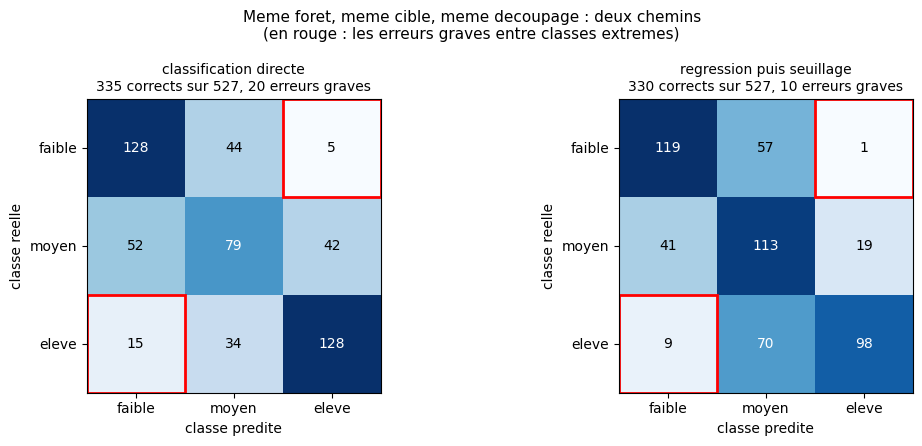

In [34]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axe, (titre, matrice) in zip(axes, [
        ("classification directe", matrice_directe),
        ("regression puis seuillage", matrice_indirecte)]):
    axe.imshow(matrice, cmap="Blues")
    axe.set_xticks(range(3), CLASSES)
    axe.set_yticks(range(3), CLASSES)
    axe.set_xlabel("classe predite")
    axe.set_ylabel("classe reelle")
    graves = matrice[0, 2] + matrice[2, 0]
    axe.set_title(f"{titre}\n{matrice.trace()} corrects sur {matrice.sum()}, "
                  f"{graves} erreurs graves", fontsize=10)
    for ligne in range(3):
        for colonne in range(3):
            axe.text(colonne, ligne, matrice[ligne, colonne], ha="center",
                     va="center",
                     color="white" if matrice[ligne, colonne]
                     > matrice.max() / 2 else "black")
    # Encadrer les deux cases d'erreur grave.
    for ligne, colonne in [(0, 2), (2, 0)]:
        axe.add_patch(plt.Rectangle((colonne - 0.5, ligne - 0.5), 1, 1,
                                    fill=False, edgecolor="red", linewidth=2))

figure.suptitle("Meme foret, meme cible, meme decoupage : deux chemins\n"
                "(en rouge : les erreurs graves entre classes extremes)",
                fontsize=11)
figure.tight_layout()
figure.savefig(OUT / "classification_contre_regression.png", dpi=150)
plt.show()

### Le resultat, et ce qu'il implique

**Les deux chemins atteignent une exactitude globale pratiquement identique.**
Tous deux sont tres au-dessus du plancher de 33 % correspondant au hasard, donc
la qualite ainsi definie est bien apprenable sous forme de classes, et pas
seulement sous forme de score.

**Mais regresser puis seuiller divise par deux le nombre d'erreurs graves**, et
obtient un F1 macro legerement meilleur.

L'explication est celle annoncee : le regresseur exploite l'ordre des classes,
que le classifieur ignore. Quand le regresseur se trompe, il se trompe d'un
peu, donc d'un cran de classe au plus. Le classifieur, lui, peut placer une
soudure du tiers inferieur dans le tiers superieur sans que rien dans sa
fonction de cout ne l'en dissuade particulierement.

Les matrices montrent aussi un effet classique : le regresseur place plus de
soudures dans la classe du milieu. Ses predictions sont en effet contractees
vers la moyenne, puisqu'il predit une esperance conditionnelle et non un
tirage. Il est donc naturellement prudent, ce qui le rend meilleur sur la
classe centrale et legerement moins bon sur les extremes.

On remarque enfin, dans les deux matrices, que **les deux classes extremes sont
mieux reconnues que la classe du milieu.** C'est structurel et non un defaut de
modele : une soudure `moyen` est definie comme etant entre deux seuils
conventionnels, donc entouree de voisins proches des deux cotes, et la moindre
imprecision la fait basculer. Les soudures `faible` et `eleve` ne sont bornees
que d'un cote et occupent des regions franchement distinctes de l'espace des
compositions.

> **Conclusion operationnelle.** Pour obtenir une sortie en classes, il vaut
> mieux **conserver le modele de regression et seuiller ses predictions** que
> d'entrainer un classifieur. Le travail de regression deja realise dans les
> notebooks 03 a 07 n'est donc pas a refaire : il suffit de lui ajouter l'etape
> de decoupage definie en 5.2 si une sortie categorielle est souhaitee.

### 5.4 Ouverture : ce qu'un notebook dedie devrait faire

Le resultat ci-dessus repond a la question posee, mais il ne clot pas le sujet,
et il serait malhonnete de le presenter comme tel. Il comporte une limite
precise : **la comparaison a ete faite a hyperparametres fixes**, ceux de la
regression, afin que seul le chemin varie. Un classifieur regle specifiquement
pour la classification pourrait reduire l'ecart, voire l'inverser.

Trancher ce point demanderait un travail d'une autre ampleur, qui sortirait du
cadre de ce notebook consacre au choix de la cible. Nous le reservons donc a un
notebook dedie, dont le programme serait le suivant.

**1. Comparer les familles de modeles de classification.** Arbre de decision,
foret aleatoire, boosting, regression logistique, k plus proches voisins, SVM a
noyau, bayesien naif. Chacune repose sur une hypothese differente sur la forme
des frontieres entre classes, et le corpus est assez petit pour que toutes
soient calculables.

**2. Regler les hyperparametres de chacune**, avec le meme soin que pour la
regression : grilles de recherche, validation croisee par groupes, et verification
que l'optimum retenu n'est pas au bord de la grille.

**3. Ne pas oublier la mise a l'echelle.** Les modeles qui raisonnent en
distances ou en produits scalaires, soit les k plus proches voisins, le SVM et
la regression logistique, exigent un `StandardScaler` dans leur pipeline : sans
cela une variable en centaines de ppm ecraserait mecaniquement une variable en
pourcentages, non parce qu'elle est plus informative mais parce que ses nombres
sont plus grands. Les arbres et les forets n'en ont pas besoin, puisqu'ils ne
comparent que des seuils a l'interieur d'une meme variable.

**4. Tester une approche ordinale.** Nos trois classes sont ordonnees, ce
qu'aucun classifieur standard n'exploite. La encore deux pistes : des
classifieurs binaires emboites, ou simplement la voie du seuillage de
regression validee ci-dessus, qui en est une forme simple et efficace.

**5. Reprendre l'indicateur d'erreurs graves** comme critere de selection a
cote de l'exactitude, puisque c'est lui qui porte l'enjeu industriel.

**6. Interroger le nombre de classes.** Trois est un choix defendable mais pas
le seul. Deux classes conviendraient mieux a une decision binaire
d'acceptation, et il faudrait verifier que les conclusions resistent a ce
changement.

In [35]:
comparaison_chemins.to_csv(OUT / "classification_contre_regression.csv",
                           index_label="chemin")
pd.DataFrame(matrice_indirecte, index=CLASSES, columns=CLASSES).to_csv(
    OUT / "confusion_regression_seuillee.csv", index_label="classe_reelle")
controle.to_csv(OUT / "decoupage_classes.csv", index_label="classe")

print("resultats de la section 5 enregistres.")

resultats de la section 5 enregistres.


## 6. Ce que cette demarche ne peut pas etablir

Cette section est volontairement placee avant la conclusion, et non en annexe.
Les limites qui suivent ne sont pas des reserves de forme : elles delimitent
exactement la portee de tout ce qui precede.

### 6.1 La limite principale : il n'existe pas de verite de reference

Le jeu de donnees ne contient **aucune variable de qualite**. Il contient des
proprietes mecaniques mesurees. Toute definition de la qualite est donc une
construction de notre part, y compris celle que nous allons recommander.

En consequence, **aucun des quatre criteres de la section 3, ni les resultats de
modelisation des sections 4 et 5, ne peut demontrer qu'une definition est la
bonne.** Ce qu'ils etablissent est plus modeste et plus honnete : parmi les
definitions candidates, certaines ont des proprietes verifiables que les autres
n'ont pas. C'est un argument de coherence, pas une preuve de verite.

Si un expert en soudage fournissait une regle differente, par exemple une norme
imposant un allongement minimal absolu, elle primerait sur tout ce notebook.
Notre demarche est celle que l'on peut mener **en l'absence** d'une telle regle,
et elle doit etre presentee comme telle.

### 6.2 Les limites de methode

**Le choix de la formule d'agregation, et c'est la limite de methode la plus
serieuse.** La section 8.2 la mesure precisement. L'operateur retenu, la
moyenne geometrique, peut etre remplace par le minimum ou par une moyenne
arithmetique sans bouleverser le classement : une large majorite des meilleures
soudures reste la meme. En revanche, **deplacer la ponderation entre resistance
et ductilite ne conserve qu'environ la moitie du meilleur cinquieme.** Selon la
ponderation, on recommanderait donc pour moitie des soudures differentes.

Deux elements limitent la portee de cette reserve, sans l'annuler. D'une part le
notebook 02 avait trouve exactement la meme ampleur sur sa propre cible : la
sensibilite est inherente a ce type de score de compromis et ne differencie pas
les deux definitions. D'autre part l'equilibre 50/50 n'est pas un reglage parmi
d'autres, c'est le seul traitement neutre possible en l'absence d'information
sur l'usage final de la soudure, et c'est celui dont la section 3.3 a verifie
les consequences. Il reste que ce choix est une convention et non un resultat,
et le rapport doit le presenter ainsi.

**Le choix du domaine de calibration.** Calibrer les rangs sur les lignes ou
chaque mesure existe, ou sur les seules lignes ou toutes les mesures existent,
decale le score de quelques pourcents. Ce point a ete explicite en section 2 ;
il est mineur mais reel.

**Les hyperparametres.** Les sections 4 et 5 utilisent un jeu
d'hyperparametres unique, repris du notebook 05, afin que la seule chose qui
varie soit la cible, puis le chemin. C'est le bon choix pour ces comparaisons,
mais cela signifie que les performances absolues rapportees ici ne sont pas
optimisees. Elles ne doivent pas etre citees comme les performances finales du
projet. La section 5.4 detaille ce que cette limite implique pour la
classification en particulier.

**L'absence de verification sur l'ensemble de test.** Tout ce notebook
travaille sur l'ensemble de developpement. L'ensemble de test est reste
intouche, ce qui est volontaire : il doit servir une seule fois, a la fin, sur
le modele finalement retenu. Les chiffres presentes ici sont donc des
estimations par validation croisee, pas des performances finales.

### 6.3 Les limites des donnees

**Le corpus est observationnel.** Il rassemble des essais publies par divers
laboratoires, et non une experience planifiee. Les compositions et les
procedes y sont correles par les pratiques industrielles, ce qui empeche
d'isoler l'effet propre d'une variable. Les importances de la section 4
doivent se lire comme des associations, pas comme des effets causaux.

**Les donnees manquantes ne sont pas aleatoires.** Le notebook 01 a etabli
qu'elles suivent le protocole experimental : un laboratoire qui fait un essai
de traction ne fait generalement pas d'essai Charpy. C'est pourquoi les cibles
de traction et de tenacite ne peuvent pas etre combinees en une cible unique
sans imputer massivement, et pourquoi la section 3 a traite les deux familles
separement plutot que de forcer leur fusion.

**L'effectif reste modeste.** Un peu plus de 500 lignes utilisables pour la
cible retenue, correspondant a moins de 400 soudures distinctes. Les ecarts de
quelques points entre les lignes voisines des tableaux ci-dessus sont du meme
ordre que la dispersion entre plis : ils ne doivent pas etre
surinterpretes.

## 7. Conclusion et recommandation

### 7.1 Ce qui a ete fait

Le notebook 02 avait retenu, sans comparaison explicite, une cible combinant la
resistance a la traction et l'allongement. Ce notebook a construit cinq
definitions candidates de la qualite, couvrant la resistance seule, la
resistance et la ductilite, les quatre proprietes de traction, la tenacite
brute et la tenacite corrigee de la temperature d'essai, puis les a comparees
selon six angles independants :

1. la **couverture**, soit l'effectif de soudures pour lesquelles la cible est calculable ;
2. l'**accord** entre definitions, par correlation des rangs et recouvrement des meilleures soudures ;
3. la **coherence physique**, soit la verification que les soudures bien notees sont bonnes sur toutes les proprietes ;
4. la **robustesse** de la cible a un rechantillonnage des donnees ;
5. la **predictibilite** a partir de la composition et du procede ;
6. la **transposition en classes**, et le choix du chemin pour y parvenir.

Les quatre premiers criteres ne font appel a aucun modele, ce qui etait un
choix delibere : si la cible avait ete choisie sur la performance d'un modele,
le raisonnement aurait ete circulaire.

In [36]:
# On complete la synthese sans modele de la section 3 par la colonne de
# predictibilite obtenue en section 4. Les cibles non evaluees par un modele
# recoivent une valeur manquante, ce qui est plus honnete qu'un zero.
gain_par_libelle = predictibilite["gain_sur_reference"].rename(
    index={nom: LIBELLES[nom] for nom in predictibilite.index})

synthese_finale = synthese.copy()
synthese_finale["gain_sur_reference"] = gain_par_libelle
synthese_finale.round(3)

,mesures_combinees,lignes_exploitables,desequilibre_absolu,proprietes_au_dessus_moyenne,jaccard_moyen,gain_sur_reference
y1 UTS seule,1,738,0.660,2,1.000,0.512
y2 UTS + allongement (actuelle),2,666,0.092,3,0.929,0.314
y3 quatre proprietes de traction,4,650,0.053,5,0.931,0.374
y4 tenacite Charpy brute,1,879,0.846,3,1.000,NaN
y5 tenacite a temperature comparable,2,879,0.478,3,0.922,0.258


### 7.2 Ce que les resultats etablissent

**Sur le choix de la cible.** La definition fondee sur les quatre proprietes de
traction, `y3`, est la seule a satisfaire les quatre criteres sans modele a la
fois. Elle est la seule dont le meilleur cinquieme est effectivement bon sur
l'ensemble des proprietes mesurees, elle est la plus robuste au
rechantillonnage, et elle couvre presque autant de soudures que la cible
actuelle. La section 4 a de plus montre qu'elle est **mieux predite** que la
cible actuelle, ce qui leve la derniere objection possible au changement.

**Sur ce qu'il faut ecarter.** La cible fondee sur la resistance seule, `y1`,
doit etre rejetee malgre d'excellents resultats de modelisation. Son meilleur
cinquieme reunit les soudures les moins ductiles du corpus : un modele entraine
sur elle recommanderait des soudures fragiles, avec une grande confiance. C'est
le resultat le plus important de ce notebook, et il n'aurait pas pu etre obtenu
par une comparaison de performances.

**Sur la tenacite.** Elle merite d'etre traitee, mais **separement** et non
fusionnee avec la traction. Les essais Charpy portent en effet sur d'autres
soudures que les essais de traction, et la tenacite est la propriete que les
auteurs du jeu de donnees jugent la plus importante pour une soudure. La
corriger de la temperature d'essai est indispensable, faute de quoi le modele
apprend surtout la temperature. Sa predictibilite est plus faible, pour des
raisons intrinseques a la mesure, et cela doit etre annonce.

**Sur la classification.** Elle fonctionne : les deux chemins testes sont tres
au-dessus du hasard. Mais a hyperparametres egaux, seuiller les predictions du
modele de regression fait aussi bien que classer directement, avec deux fois
moins d'erreurs graves. Une etude complete des modeles de classification reste
a mener, et la section 5.4 en donne le programme.

### 7.3 Recommandation pour la suite du projet

Quatre propositions, dans l'ordre de priorite.

**1. Adopter `y3` comme cible principale, sans supprimer le travail existant.**
La cible du notebook 02 et la nouvelle sont fortement correlees et partagent une
bonne part de leurs meilleures soudures : le changement est une amelioration de
la definition, pas un desaveu. Le plus honnete, et le plus informatif pour la
lecture du projet, est de reentrainer les modeles sur `y3` et de presenter les
deux series de resultats cote a cote.

**2. Conserver la regression comme formulation principale**, et ajouter le
decoupage en trois classes en aval si une sortie categorielle est utile. Cela
evite de dupliquer le reglage des hyperparametres, et c'est le chemin qui
produit le moins d'erreurs graves.

**3. Traiter la tenacite corrigee de la temperature comme un second probleme**,
sur son propre ensemble de soudures. Cela elargit la portee du projet aux
quelques centaines de soudures que la cible de traction laisse de cote, et
repond a la propriete que la litterature sur ce jeu de donnees juge la plus
importante.

**4. Documenter ce cheminement dans le rapport final.** Le fait d'avoir
identifie puis evite le piege de `y1` est un resultat en soi. Il montre que le
choix de la cible a ete instruit et non suppose, ce qui est precisement la
difficulte centrale de ce projet, puisque la variable a predire n'existe pas
dans les donnees et devait etre construite.

Un cinquieme chantier, de priorite moindre, est detaille en section 5.4 : une
etude complete des modeles de classification, dans un notebook dedie.

### 7.4 En une phrase

En l'absence de variable de qualite dans les donnees, la definition la plus
defendable est la moyenne geometrique du rang de resistance et du rang de
ductilite, car c'est la seule qui soit a la fois bien couverte, stable,
coherente avec l'ensemble des proprietes mesurees, et mieux predite que la
definition actuellement utilisee par le projet.

In [37]:
synthese_finale.to_csv(OUT / "synthese_criteres.csv", index_label="cible")
print("synthese enregistree.")

synthese enregistree.


## 8. Produire la cible retenue pour la suite du projet

Les sept sections precedentes ont compare des definitions. Celle-ci en produit
une, sous une forme directement utilisable par les notebooks de modelisation.

Ce notebook reprend donc le role que le notebook 02 tenait jusqu'ici : fournir
le jeu de donnees avec sa cible. Trois precautions, heritees de ce notebook 02,
doivent etre reprises ici, faute de quoi le remplacement ferait perdre du
travail deja fait.

### 8.1 Controles de validite physique

Le notebook 02 ne se contentait pas de verifier que les mesures sont presentes :
il verifiait aussi qu'elles sont physiquement plausibles. Une resistance
negative ou un allongement de 300 % traduirait une erreur de saisie ou de
nettoyage, et contaminerait silencieusement le calibrage des rangs.

On reprend ces controles, etendus aux quatre mesures de la cible retenue, et on
en ajoute un que le notebook 02 ne pouvait pas faire puisqu'il n'utilisait
qu'une seule mesure de resistance : **la resistance a la traction doit etre
superieure ou egale a la limite d'elasticite.** C'est une contrainte physique
absolue, puisque la limite d'elasticite est le seuil ou le materiau commence a
se deformer durablement, tandis que la resistance a la traction est la
contrainte maximale qu'il supporte avant rupture. Une ligne qui violerait cette
inegalite serait forcement erronee.

In [38]:
# Bornes physiques admissibles pour chaque mesure de la cible.
BORNES_PHYSIQUES = {
    "YieldStrength_MPa": (0, 2000),    # une limite d'elasticite est positive
    "UTS_MPa": (0, 2500),              # idem pour la resistance a la traction
    "Elongation_pct": (0, 100),        # un allongement est un pourcentage
    "ReductionArea_pct": (0, 100),     # une striction aussi
}

rapport_validite = []
for mesure, (minimum, maximum) in BORNES_PHYSIQUES.items():
    valeurs = propre[mesure].dropna()
    hors_bornes = ((valeurs <= minimum) | (valeurs > maximum)).sum()
    non_finies = (~np.isfinite(valeurs)).sum()
    rapport_validite.append({
        "mesure": mesure, "renseignees": len(valeurs),
        "minimum observe": valeurs.min(), "maximum observe": valeurs.max(),
        "hors bornes": int(hors_bornes), "non finies": int(non_finies),
    })

rapport_validite = pd.DataFrame(rapport_validite).set_index("mesure")

# Controle de coherence entre les deux mesures de resistance.
comparables = propre[["UTS_MPa", "YieldStrength_MPa"]].dropna()
taux_ecrouissage = comparables["UTS_MPa"] / comparables["YieldStrength_MPa"]

impossibles = int((taux_ecrouissage < 1.0).sum())
# Un rapport proche de 1 signifie un ecrouissage quasi nul, physiquement tres
# improbable dans un acier ductile. Le seuil de 1,05 est indicatif.
SEUIL_ECROUISSAGE = 1.05
douteuses = taux_ecrouissage[taux_ecrouissage < SEUIL_ECROUISSAGE]

print(f"Lignes ou les deux resistances sont connues : {len(comparables)}")
print(f"Taux d'ecrouissage (UTS sur limite d'elasticite) : "
      f"median {taux_ecrouissage.median():.3f}, "
      f"minimum {taux_ecrouissage.min():.3f}")
print(f"Lignes ou UTS < limite d'elasticite (impossible) : {impossibles}")
print(f"Lignes au taux inferieur a {SEUIL_ECROUISSAGE} (douteuses) : "
      f"{len(douteuses)}")

assert rapport_validite["hors bornes"].sum() == 0, "valeur hors bornes physiques"
assert rapport_validite["non finies"].sum() == 0, "valeur non finie"
assert impossibles == 0, "UTS inferieure a la limite d'elasticite"
print("\nLes bornes et l'inegalite entre les deux resistances passent.")
rapport_validite.round(2)

Lignes ou les deux resistances sont connues : 714
Taux d'ecrouissage (UTS sur limite d'elasticite) : median 1.179, minimum 1.000
Lignes ou UTS < limite d'elasticite (impossible) : 0
Lignes au taux inferieur a 1.05 (douteuses) : 5

Les bornes et l'inegalite entre les deux resistances passent.


,renseignees,minimum observe,maximum observe,hors bornes,non finies
mesure,,,,,
YieldStrength_MPa,780,315.0,920.0,0,0
UTS_MPa,738,447.0,1151.0,0,0
Elongation_pct,700,10.6,37.0,0,0
ReductionArea_pct,705,17.0,83.0,0,0


**Les bornes passent toutes, et l'inegalite entre les deux resistances aussi.**
C'etait l'issue attendue, le nettoyage du notebook 01 ayant deja ecarte les
valeurs non interpretables. Que l'inegalite passe partout est un indice de plus
que les deux mesures de resistance sont coherentes entre elles, ce qui justifie
de les moyenner au sein de leur famille.

**En revanche le controle plus fin signale quelques lignes.** Le rapport entre
les deux resistances s'appelle le taux d'ecrouissage. Il mesure de combien un
materiau se renforce entre le moment ou il commence a se deformer durablement
et celui ou il casse. Sa valeur mediane dans le corpus est d'environ 1,18, ce
qui est normal pour un acier. Un taux exactement egal a 1,000 signifierait un
ecrouissage nul, autrement dit un materiau qui rompt des qu'il quitte son
domaine elastique. Cela ne se produit pas dans un acier ductile.

La section suivante examine ces lignes, car elles se sont manifestees d'une
facon que nous n'avions pas anticipee.

#### Les lignes au taux d'ecrouissage anormal

Ce controle n'etait pas prevu au depart. Il a ete ajoute apres coup, parce que
le notebook 09, qui entraine les modeles sur la cible retenue, s'est trompe
lourdement sur deux soudures du jeu de test, et parce que l'examen de ces deux
soudures a conduit ici.

In [39]:
lignes_douteuses = propre.loc[douteuses.index,
                             ["WeldID"] + RESISTANCE + DUCTILITE].copy()
lignes_douteuses["taux_ecrouissage"] = douteuses
lignes_douteuses["partition"] = partition.loc[douteuses.index]
lignes_douteuses["dans_la_cible_y3"] = domaine(
    COMPOSITION_CIBLES["y3"]).loc[douteuses.index]

# D'ou viennent ces lignes ? Le WeldID commence par le nom du premier auteur
# de la publication d'origine.
publication = lignes_douteuses["WeldID"].str.split("-").str[0]
print("Publications d'origine de ces lignes :")
print(publication.value_counts().to_string())
print()
lignes_douteuses.sort_values("taux_ecrouissage")

Publications d'origine de ces lignes :


WeldID
Pat           3
Evans         1
SurianEtAl    1



,WeldID,YieldStrength_MPa,UTS_MPa,Elongation_pct,ReductionArea_pct,taux_ecrouissage,partition,dans_la_cible_y3
row_id,,,,,,,,
975,Pat-1981-S2Mo/BX200,554.0,554.0,30.0,67.0,1.000000,test,True
980,Pat-1981-S4Mo/BX200,747.0,747.0,25.0,62.0,1.000000,developpement,True
1020,Pat-1981-S4Mo/BX400,689.0,689.0,34.0,69.0,1.000000,test,True
705,SurianEtAl-C-1991-0.05htCh,673.0,680.0,23.8,NaN,1.010401,developpement,False
259,Evans-Cr/CMn-1989-1.0D-aw,692.0,723.0,21.6,70.9,1.044798,developpement,True


In [40]:
# Croisement avec les erreurs du notebook 09, si ses resultats sont presents.
chemin_predictions = ROOT / "outputs/09/predictions_test.csv"
if chemin_predictions.exists():
    predictions = pd.read_csv(chemin_predictions, index_col="row_id")
    colonne_foret = [c for c in predictions.columns
                     if c.lower().startswith("for")][0]
    predictions["erreur_absolue"] = (predictions[colonne_foret]
                                     - predictions["score_reel"]).abs()
    pires = predictions.nlargest(5, "erreur_absolue").copy()
    pires["taux_ecrouissage"] = taux_ecrouissage.reindex(pires.index)
    pires["signalee_douteuse"] = pires.index.isin(douteuses.index)

    print("Les cinq plus grosses erreurs du modele sur le jeu de test :")
    display(pires[["score_reel", colonne_foret, "erreur_absolue",
                   "taux_ecrouissage", "signalee_douteuse"]].round(3))

    part_corpus = len(douteuses) / len(comparables)
    print(f"Parmi ces cinq erreurs, {int(pires['signalee_douteuse'].sum())} "
          "sont signalees par le controle d'ecrouissage,")
    print(f"alors que les lignes douteuses ne representent que "
          f"{part_corpus:.1%} des lignes ou le controle est calculable.")
else:
    print("Resultats du notebook 09 absents de ce clone, croisement non fait.")
    print("Executer le notebook 09 puis relancer cette cellule.")

Les cinq plus grosses erreurs du modele sur le jeu de test :


,score_reel,Forêt aleatoire,erreur_absolue,taux_ecrouissage,signalee_douteuse
row_id,,,,,
1020,0.751,0.355,0.396,1.000,True
975,0.539,0.281,0.259,1.000,True
1144,0.433,0.188,0.245,1.119,False
554,0.565,0.367,0.197,1.195,False
362,0.561,0.414,0.148,1.132,False


Parmi ces cinq erreurs, 2 sont signalees par le controle d'ecrouissage,
alors que les lignes douteuses ne representent que 0.7% des lignes ou le controle est calculable.


#### Ce que cela etablit, et la decision prise

**Il faut distinguer deux cas parmi les lignes signalees, et le tableau le
montre bien.**

**Trois lignes ont un taux exactement egal a 1,000**, c'est-a-dire deux
resistances rigoureusement identiques au megapascal pres. Ces trois lignes
viennent **toutes de la meme publication**. Ce n'est donc pas une erreur
dispersee au hasard dans le corpus, c'est un defaut localise, et l'explication
la plus economique est que cette publication ne rapportait qu'une seule valeur
de resistance, recopiee dans les deux colonnes lors de la constitution du jeu
de donnees. L'egalite exacte de deux mesures physiques independantes est en
elle-meme improbable, meme sans argument metallurgique.

**Les deux autres lignes ont des taux de 1,010 et 1,045**, qui proviennent de
deux publications differentes. Ces valeurs sont basses mais pas impossibles :
certains aciers fortement allies, deja proches de leur limite, s'ecrouissent
tres peu. Rien ne permet de les mettre en doute, et le seuil de 1,05 les
attrape surtout parce qu'il est volontairement prudent. Nous ne les considerons
donc pas comme suspectes.

La suspicion porte ainsi sur trois lignes, pas cinq.

**Les deux plus grosses erreurs du modele sont precisement les deux lignes a
taux exactement 1,000 qui se trouvent dans le jeu de test**, alors que ces
lignes representent moins de 1 % du corpus. La coincidence est trop forte pour
etre fortuite. Ce que nous avions d'abord pris pour une faiblesse du modele est
donc plus probablement un defaut des donnees, que le modele a mis en evidence.

Le mecanisme est comprehensible. Pour ces lignes, la limite d'elasticite a
vraisemblablement ete remplacee par la resistance a la traction, donc surevaluee.
Le rang de resistance qui en decoule est trop eleve, et le score de la soudure
devient anormalement bon au regard de sa composition. Le modele, qui n'a pas vu
cette erreur de saisie, predit le score que la composition laisse attendre, et
se retrouve tres loin du score errone.

C'est un usage reel et reconnu d'un modele predictif : **quand un modele bien
construit se trompe lourdement sur un petit nombre de points, il faut examiner
ces points avant de mettre en cause le modele.** Un point aberrant pour un
modele est souvent un point aberrant tout court.

**Decision : ces lignes sont signalees mais conservees.** Trois raisons.

D'abord, nous n'avons pas acces a la publication d'origine pour confirmer
l'erreur. Ecarter des donnees sur une presomption, meme forte, demande une
verification dont nous ne disposons pas.

Ensuite, deux des trois lignes suspectes sont dans le jeu de test. Les en
retirer apres avoir constate qu'elles degradent nos resultats serait une faute
de methode : on ne nettoie pas un jeu de test au vu des erreurs qu'il revele,
sinon on mesure la performance sur des donnees choisies pour etre favorables.

Enfin leur poids dans l'ajustement est negligeable : trois lignes sur plus de
six cents, et la ponderation par soudure reduit encore leur influence. Les
conserver ne fausse pas les resultats d'ensemble, alors que les retirer
obligerait a reexecuter toute la chaine en aval pour un effet tres faible.

La bonne facon de traiter ce point est donc de le **documenter**, ce que fait
cette section, et de signaler que les deux erreurs les plus spectaculaires du
notebook 09 ont cette origine. Un lecteur qui verrait seulement le nuage de
points des predictions pourrait croire a une defaillance du modele sur les
soudures a haute resistance ; il sait maintenant que ce n'en est pas une.

**Ce qu'il faut en retenir pour le rapport est double.** D'une part le corpus
contient des defauts residuels malgre le nettoyage du notebook 01, ce qui est
attendu pour une compilation de resultats publies par des laboratoires
differents sur plusieurs decennies. D'autre part l'examen des erreurs d'un
modele est un moyen efficace de les trouver, et c'est un resultat que nous
n'avions pas anticipe.

### 8.2 La ponderation choisie est-elle la bonne ?

Le notebook 02 avait pose une question importante, qu'il faut reprendre ici.
Son score combinait deux mesures a parts egales, et il verifiait que ce choix
de 50/50 n'etait pas determinant, en le comparant a des ponderations 25/75 et
75/25.

La cible retenue, `y3`, repose sur **trois choix d'agregation** qui n'ont pas
encore ete testes :

1. a l'interieur de chaque famille, les deux mesures sont **moyennees** ;
2. entre les deux familles, les rangs sont combines par **moyenne geometrique** ;
3. cette combinaison est **equilibree**, resistance et ductilite comptant autant.

Chacun de ces choix est defendable, mais aucun n'est impose. On les fait donc
varier et on mesure l'effet sur le classement des soudures, avec les deux memes
indicateurs que la section 3 : la **correlation des rangs de Spearman**, qui
dit si l'ordre general est conserve, et le **recouvrement du meilleur
cinquieme**, qui dit si on recommanderait les memes soudures.

Si les variantes restent proches de la reference, alors le classement ne depend
pas de ces conventions, et la cible est solide. Si elles s'en ecartent
fortement, il faudra le signaler comme une limite.

In [41]:
def variantes_de_y3(lignes_calibration):
    """Construit y3 et plusieurs variantes d'agregation, sur le meme domaine.

    Toutes les variantes partent des memes rangs calibres, de sorte que seule
    la facon de les combiner differe.
    """
    rangs = pd.DataFrame(index=propre.index)
    for mesure in RESISTANCE + DUCTILITE:
        reference = reference_rangs(propre.loc[lignes_calibration, mesure],
                                    groupes.loc[lignes_calibration])
        rangs[mesure] = appliquer_rangs(propre[mesure], reference)

    # Agregation par famille : moyenne, ou variante par le minimum.
    res_moyenne = rangs[RESISTANCE].mean(axis=1)
    duc_moyenne = rangs[DUCTILITE].mean(axis=1)
    res_minimum = rangs[RESISTANCE].min(axis=1)
    duc_minimum = rangs[DUCTILITE].min(axis=1)

    variantes = {
        "reference y3": np.sqrt(res_moyenne * duc_moyenne),
        "exposant resistance 0.25": res_moyenne ** 0.25 * duc_moyenne ** 0.75,
        "exposant resistance 0.75": res_moyenne ** 0.75 * duc_moyenne ** 0.25,
        "moyenne arithmetique": (res_moyenne + duc_moyenne) / 2,
        "minimum des deux familles": pd.concat(
            [res_moyenne, duc_moyenne], axis=1).min(axis=1),
        "minimum dans chaque famille": np.sqrt(res_minimum * duc_minimum),
        "une mesure par famille (UTS, allongement)": np.sqrt(
            rangs["UTS_MPa"] * rangs["Elongation_pct"]),
    }
    masque = domaine(RESISTANCE + DUCTILITE)
    return {nom: valeur.where(masque) for nom, valeur in variantes.items()}


variantes = variantes_de_y3(dev)
reference_variante = variantes["reference y3"].loc[index_y3]
top_reference = quintile_de(reference_variante)

lignes_sensibilite = []
for nom, valeur in variantes.items():
    serie = valeur.loc[index_y3]
    top_variante = quintile_de(serie)
    lignes_sensibilite.append({
        "variante": nom,
        "correlation de Spearman": reference_variante.corr(serie,
                                                           method="spearman"),
        "recouvrement du top 20 %": len(top_reference & top_variante)
                                     / len(top_reference),
        "ecart maximal de score": (serie - reference_variante).abs().max(),
    })

sensibilite = pd.DataFrame(lignes_sensibilite).set_index("variante")
sensibilite.round(3)

,correlation de Spearman,recouvrement du top 20 %,ecart maximal de score
variante,,,
reference y3,1.000,1.000,0.000
exposant resistance 0.25,0.619,0.547,0.240
exposant resistance 0.75,0.782,0.519,0.240
moyenne arithmetique,0.817,0.811,0.438
minimum des deux familles,0.937,0.736,0.242
minimum dans chaque famille,0.891,0.783,0.389
"une mesure par famille (UTS, allongement)",0.807,0.585,0.333


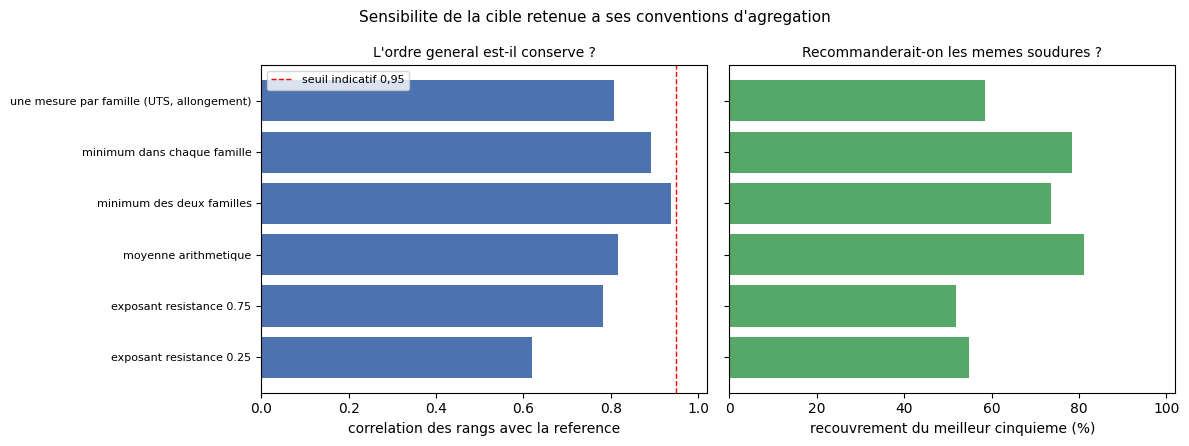

In [42]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
noms = [n for n in sensibilite.index if n != "reference y3"]
positions = np.arange(len(noms))

axes[0].barh(positions, sensibilite.loc[noms, "correlation de Spearman"],
             color="#4C72B0")
axes[0].set_yticks(positions, noms, fontsize=8)
axes[0].set_xlim(0, 1.02)
axes[0].axvline(0.95, color="red", linestyle="--", linewidth=1,
                label="seuil indicatif 0,95")
axes[0].set_xlabel("correlation des rangs avec la reference")
axes[0].set_title("L'ordre general est-il conserve ?", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].barh(positions, 100 * sensibilite.loc[noms, "recouvrement du top 20 %"],
             color="#55A868")
axes[1].set_yticks(positions, [""] * len(noms))
axes[1].set_xlim(0, 102)
axes[1].set_xlabel("recouvrement du meilleur cinquieme (%)")
axes[1].set_title("Recommanderait-on les memes soudures ?", fontsize=10)

figure.suptitle("Sensibilite de la cible retenue a ses conventions "
                "d'agregation", fontsize=11)
figure.tight_layout()
figure.savefig(OUT / "sensibilite_agregation.png", dpi=150)
plt.show()

### Ce que montre l'etude de sensibilite

Le resultat n'est pas celui qu'on pourrait esperer, et il faut le dire
franchement : **la cible est sensible a ses conventions d'agregation.** Aucune
variante ne reproduit la reference. Il faut donc regarder de plus pres quelles
conventions comptent, et a quel point.

**Le choix de l'operateur a un effet modere.** Remplacer la moyenne geometrique
par le minimum des deux familles conserve l'essentiel de l'ordre, et agreger
par le minimum a l'interieur de chaque famille reste proche. La moyenne
arithmetique s'ecarte davantage de l'ordre general, mais conserve neanmoins une
large majorite du meilleur cinquieme. Autrement dit, ces variantes
reclasseraient les soudures moyennes entre elles, mais recommanderaient en
grande partie les memes bonnes soudures. C'est l'usage qui nous interesse, donc
cet effet est acceptable.

**La ponderation entre resistance et ductilite a un effet fort.** Donner trois
fois plus de poids a l'une qu'a l'autre ne conserve qu'environ la moitie du
meilleur cinquieme. C'est considerable : selon la ponderation retenue, on
recommanderait pour moitie des soudures differentes.

**Ce point merite d'etre relativise par une comparaison.** Le notebook 02 avait
mene exactement la meme etude sur sa propre cible, en faisant varier le poids
entre resistance et allongement. Il avait obtenu des correlations de 0,661 et
0,736, et un recouvrement du meilleur cinquieme de 57 % et 56 %. Nos valeurs
sur `y3` sont du meme ordre. **Cette sensibilite n'est donc pas un defaut de la
nouvelle cible : c'est une propriete de ce type de score de compromis, deja
presente dans la cible actuelle et deja documentee par le notebook 02.** Elle
ne differencie pas les deux definitions, elle les concerne toutes les deux.

**Pourquoi conserver malgre tout l'equilibre 50/50.** Puisque le choix compte,
il faut le justifier plutot que de le subir. Trois arguments.

D'abord, aucune information exterieure ne permettrait de faire autrement :
privilegier la resistance ou la ductilite supposerait de connaitre l'usage
final de la soudure, ce que le jeu de donnees ne dit pas. En l'absence de cette
information, le traitement symetrique est le seul neutre.

Ensuite, l'equilibre est precisement la propriete que la section 3.3 a validee :
le quintile superieur de `y3` est bon sur les cinq proprietes mesurees, ce
qu'aucune autre candidate ne realise. Un `y3` fortement desequilibre perdrait
cette propriete et se rapprocherait des cibles ecartees.

Enfin, c'est le choix deja fait par le notebook 02, donc le conserver maintient
la comparabilite entre l'ancienne cible et la nouvelle : si l'on changeait a la
fois les mesures et leur ponderation, on ne saurait plus a quoi attribuer les
ecarts de resultats.

**Un controle de coherence, au passage.** La derniere variante, qui ne garde
qu'une mesure par famille, est exactement la construction de la cible actuelle
appliquee a des rangs recalibres. Sa correlation avec `y3` reproduit celle que
la section 3.2 avait mesuree entre `y2` et `y3` par un chemin de calcul
different. Les deux sections se confirment mutuellement.

> **A retenir pour le rapport.** La conclusion de ce notebook porte sur **le
> perimetre des mesures retenues**, pas sur la formule d'agregation. Ajouter la
> limite d'elasticite et la striction est un gain argumente par quatre criteres
> independants. Le choix du 50/50 et de la moyenne geometrique, lui, est une
> convention neutre et non une conclusion : il doit etre presente comme tel, et
> la section 6 le reprend parmi les limites.

### 8.3 Export du jeu de donnees pour la modelisation

On produit maintenant le fichier que les notebooks de modelisation
consommeront. Deux exigences.

**Il doit respecter exactement le format du notebook 02.** Memes colonnes,
meme nom d'index, et surtout **meme nom pour la colonne de cible**,
`score_compromis`. C'est ce qui permet a un notebook de modelisation de passer
a la nouvelle cible en changeant une seule ligne, le chemin du fichier lu,
plutot qu'en etant reecrit.

**Il doit porter la colonne `partition`.** Le calibrage des rangs est fait sur
le developpement seulement, mais le fichier contient aussi les lignes de test,
marquees comme telles. L'ensemble de test reste ainsi disponible pour
l'evaluation finale, sans qu'aucune information n'ait fuite de lui vers la
construction de la cible. Comme la section 0 a verifie que cette partition est
identique a celle du notebook 02, les resultats obtenus sur l'ancienne et la
nouvelle cible seront directement comparables.

In [43]:
# La cible est calibree sur le developpement seul, puis appliquee a toutes
# les lignes de son domaine, exactement comme le faisait le notebook 02.
cible_exportee = cibles["y3"].rename("score_compromis")
lignes_exportees = cible_exportee.dropna().index

variables_X = schema["COMPOSITION"] + schema["PROCESS"]
assert not set(COMPOSITION_CIBLES["y3"]) & set(variables_X), \
    "une mesure de la cible s'est glissee dans les variables explicatives"

export = pd.concat([
    groupes.loc[lignes_exportees].rename("groupe"),
    partition.loc[lignes_exportees],
    propre.loc[lignes_exportees, ["WeldID"]],
    propre.loc[lignes_exportees, COMPOSITION_CIBLES["y3"]],
    cible_exportee.loc[lignes_exportees],
    propre.loc[lignes_exportees, variables_X],
], axis=1)

export.to_csv(OUT / "dataset_traction_y3.csv", index_label="row_id")

# Controles sur le fichier produit.
assert export["score_compromis"].between(0, 1).all()
assert export["score_compromis"].notna().all()
ancien = pd.read_csv(ROOT / "outputs/02/dataset_traction.csv",
                     index_col="row_id")
communes = export.index.intersection(ancien.index)
assert (export.loc[communes, "partition"]
        == ancien.loc[communes, "partition"]).all(), \
    "la partition differe de celle du notebook 02"

print(f"dataset_traction_y3.csv : {len(export)} lignes, "
      f"{export.shape[1]} colonnes, "
      f"{groupes.loc[lignes_exportees].nunique()} soudures.")
print(f"   developpement : {int((export['partition'] == 'developpement').sum())} lignes")
print(f"   test reserve  : {int((export['partition'] == 'test').sum())} lignes")
print(f"\nColonnes communes avec le fichier du notebook 02 : "
      f"{len(set(export.columns) & set(ancien.columns))} sur {export.shape[1]}")
print(f"Lignes communes : {len(communes)}, partition identique sur toutes.")
export.head(3)

dataset_traction_y3.csv : 650 lignes, 38 colonnes, 469 soudures.
   developpement : 527 lignes
   test reserve  : 123 lignes

Colonnes communes avec le fichier du notebook 02 : 36 sur 38
Lignes communes : 650, partition identique sur toutes.


,groupe,partition,WeldID,YieldStrength_MPa,UTS_MPa,Elongation_pct,ReductionArea_pct,score_compromis,C,Si,Mn,S,P,Ni,Cr,Mo,V,Cu,Co,W,O_ppm,Ti_ppm,N_ppm,Al_ppm,B_ppm,Nb_ppm,Sn_ppm,As_ppm,Sb_ppm,Current_A,Voltage_V,AC_DC,Electrode_pol,HeatInput_kJmm,InterpassT_C,WeldType,PWHT_T_C,PWHT_time_h
row_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,11,developpement,Evans-Ni/CMn-1990/1991-0Aaw,392.0,466.0,31.9,80.6,0.242736,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,21.0,DC,+,1.0,200.0,MMA,250.0,14.0
2,11,developpement,Evans-Ni/CMn-1990/1991-0Aht,370.0,456.0,35.2,80.6,0.146237,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,21.0,DC,+,1.0,200.0,MMA,580.0,2.0
3,14,developpement,Evans-Ni/CMn-1990/1991-0Baw,413.0,498.0,31.2,80.6,0.351030,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,21.0,DC,+,1.0,200.0,MMA,250.0,14.0


In [44]:
# Comparaison des deux fichiers, ancien et nouveau, pour le rapport.
comparaison_jeux = pd.DataFrame({
    "notebook 02 (y2)": {
        "mesures dans la cible": 2,
        "lignes": len(ancien),
        "soudures": groupes.loc[ancien.index].nunique(),
        "lignes de developpement": int((ancien["partition"] == "developpement").sum()),
        "colonnes": ancien.shape[1],
    },
    "notebook 08 (y3)": {
        "mesures dans la cible": len(COMPOSITION_CIBLES["y3"]),
        "lignes": len(export),
        "soudures": groupes.loc[lignes_exportees].nunique(),
        "lignes de developpement": int((export["partition"] == "developpement").sum()),
        "colonnes": export.shape[1],
    },
})
comparaison_jeux["ecart"] = (comparaison_jeux["notebook 08 (y3)"]
                             - comparaison_jeux["notebook 02 (y2)"])
comparaison_jeux

,notebook 02 (y2),notebook 08 (y3),ecart
mesures dans la cible,2,4,2
lignes,666,650,-16
soudures,480,469,-11
lignes de developpement,539,527,-12
colonnes,36,38,2


Le nouveau fichier contient un peu moins de lignes que l'ancien, ce qui est la
contrepartie mecanique de l'ajout de deux mesures : exiger quatre mesures
simultanees est plus restrictif qu'en exiger deux. L'ecart reste faible, et la
section 3.1 avait deja mesure ce cout en couverture et conclu qu'il etait
acceptable.

Les deux fichiers ont la meme structure de colonnes, aux deux mesures
supplementaires pres. Un notebook de modelisation peut donc basculer d'une
cible a l'autre en changeant le chemin du fichier.

### 8.4 Manifeste de reproductibilite

Le notebook 02 produisait un fichier `manifest.json` consignant la graine
aleatoire, la formule de la cible, la liste des lignes de developpement et de
test, et les tables de rangs completes. C'est une bonne pratique qu'il faut
reprendre, pour une raison precise : **elle permet de reconstruire la cible a
l'identique sans reexecuter ce notebook.**

C'est utile dans deux situations concretes. D'abord si un coequipier veut
verifier un resultat sans relancer quatre-vingts cellules. Ensuite, et surtout,
pour appliquer la cible a l'ensemble de test lors de l'evaluation finale : les
rangs doivent alors etre ceux calibres sur le developpement, et le manifeste
les conserve exactement.

On y ajoute les seuils de classe de la section 5, pour que la sortie
categorielle soit reproductible elle aussi.

In [45]:
references_exportees = {}
for mesure in COMPOSITION_CIBLES["y3"]:
    valeurs_grille, rangs_grille = reference_rangs(propre.loc[dev, mesure],
                                                   groupes.loc[dev])
    references_exportees[mesure] = {"valeurs": valeurs_grille.tolist(),
                                    "rangs": rangs_grille.tolist()}

manifeste = {
    "graine": GRAINE,
    "cible": "y3",
    "formule": ("sqrt(moyenne(rang_YieldStrength, rang_UTS) * "
                "moyenne(rang_Elongation, rang_ReductionArea))"),
    "mesures": COMPOSITION_CIBLES["y3"],
    "ponderation_entre_familles": 0.5,
    "calibration": ("developpement seulement ; mi-rang pondere, "
                    "poids total de 1 par soudure"),
    "nom_de_la_colonne_cible": "score_compromis",
    "fichier_produit": "outputs/08/dataset_traction_y3.csv",
    "remplace": "outputs/02/dataset_traction.csv",
    "lignes_developpement": export.index[
        export["partition"] == "developpement"].tolist(),
    "lignes_test": export.index[export["partition"] == "test"].tolist(),
    "references_de_rangs": references_exportees,
    "seuils_de_classe": {
        "classes": CLASSES,
        "coupures_en_rang": [1 / 3, 2 / 3],
        "coupures_en_score": [
            float(controle.loc["faible", "score maximum"]),
            float(controle.loc["moyen", "score maximum"]),
        ],
    },
}

(OUT / "manifest_y3.json").write_text(
    json.dumps(manifeste, ensure_ascii=False, indent=2), encoding="utf-8")

print("manifest_y3.json ecrit.")
print(f"   {len(manifeste['lignes_developpement'])} lignes de developpement, "
      f"{len(manifeste['lignes_test'])} de test")
for mesure, table in references_exportees.items():
    print(f"   reference de rangs {mesure:20s} : "
          f"{len(table['valeurs'])} valeurs distinctes")

manifest_y3.json ecrit.
   527 lignes de developpement, 123 de test
   reference de rangs YieldStrength_MPa    : 304 valeurs distinctes
   reference de rangs UTS_MPa              : 282 valeurs distinctes
   reference de rangs Elongation_pct       : 127 valeurs distinctes
   reference de rangs ReductionArea_pct    : 119 valeurs distinctes


### 8.5 Comment utiliser cette cible dans un notebook de modelisation

Pour passer un notebook de modelisation existant a la nouvelle cible, une seule
ligne change :

```python
# avant
donnees = pd.read_csv(ROOT / "outputs/02/dataset_traction.csv", index_col="row_id")

# apres
donnees = pd.read_csv(ROOT / "outputs/08/dataset_traction_y3.csv", index_col="row_id")
```

Tout le reste du code reste valable : la colonne de cible porte le meme nom
`score_compromis`, la colonne `groupe` sert toujours a `GroupKFold`, la colonne
`partition` delimite toujours le developpement, et les variables explicatives
sont les memes.

Deux points de vigilance toutefois.

**Les resultats numeriques ne seront pas identiques**, et c'est normal : la
cible a change, et l'effectif est legerement different. Il faut conserver les
anciens resultats pour les presenter en regard des nouveaux, et non les
ecraser.

**Les hyperparametres devraient etre reajustes.** Ceux retenus sur l'ancienne
cible restent un bon point de depart, mais rien ne garantit qu'ils soient
optimaux pour la nouvelle. Au minimum, il faut verifier que l'optimum retenu
n'est pas au bord de la grille de recherche.

In [46]:
print("Notebook 08 termine.")
print(f"\nFichiers produits dans {OUT.relative_to(ROOT)} :")
for chemin in sorted(OUT.iterdir()):
    print(f"   {chemin.name:42s} {chemin.stat().st_size / 1024:7.1f} ko")

Notebook 08 termine.

Fichiers produits dans outputs\08 :
   accord_definitions.png                       194.7 ko
   accords.csv                                    0.4 ko
   classification_contre_regression.csv           0.4 ko
   classification_contre_regression.png          60.6 ko
   coherence_physique.csv                         1.1 ko
   coherence_physique.png                        58.4 ko
   confusion_regression_seuillee.csv              0.1 ko
   couverture.csv                                 0.4 ko
   dataset_traction_y3.csv                      121.2 ko
   decoupage_classes.csv                          0.2 ko
   foret_contre_arbre_lisible.csv                 0.2 ko
   importance_variables.csv                       2.6 ko
   importance_variables.png                      57.2 ko
   manifest_y3.json                              44.4 ko
   predictibilite_cibles.csv                      0.5 ko
   predictibilite_cibles.png                     61.3 ko
   resultats_par_pli.csv      